# Week 2：ESP32-S3 開發環境與數位輸入輸出實驗

日期：2026-09-16

本章以ESP32-S3開發板為實驗平台，依序完成開發環境設定、程式編譯與上傳、
Serial Monitor判讀、麵包板與按鈕通斷量測、GPIO按鈕輸入，以及按鈕去抖實驗。
所有外部接線都先在斷電狀態完成並檢查，確認後才接回USB。


## 一、Unit Overview

### Teaching Objectives

By the end of this unit, students will be able to:

1. Identify the USB, GPIO, GND, BOOT, and RESET connections used in the Week 2 circuit.
2. Configure Arduino IDE, compile and upload firmware, and interpret Serial Monitor output.
3. Use a multimeter on an unpowered circuit to identify breadboard nodes and the open and
   closed states of a tactile pushbutton.
4. Build and test a pushbutton input with `INPUT_PULLUP`, and distinguish an input reading
   from a program-issued output command.
5. Explain switch bounce, trace a software debounce algorithm, and compare debounce
   intervals using controlled evidence.

### Teaching Content

This unit introduces the development and evidence workflow for an ESP32-S3 embedded
system. Students identify the physical board, configure the development environment,
compile and upload firmware, and use Serial output to determine what the running program
has actually reported. The hardware activity uses a breadboard, jumper wires, a tactile
pushbutton, and a multimeter to study nodes, GND, GPIO, `INPUT_PULLUP`, HIGH, LOW, open
circuits, closed circuits, and low-resistance short-circuit risks. The closing discussion
focuses on contact bounce, raw readings, stable states, and software debounce.

### 核心實驗流程

| 階段 | 開始狀態 | 實驗內容 | 完成條件 |
|---:|---|---|---|
| 1 | 板子未接USB | 安裝環境與辨認板卡 | 找到COM USB、BOOT、RST、GPIO與GND |
| 2 | 只接USB | Board、Port、Verify、Upload與Serial | log顯示自己的組別與`version=2` |
| 3 | USB已拔除 | 麵包板、按鈕與萬用電表通斷 | 能解釋同列、跨槽、按下與放開結果 |
| 4 | USB仍拔除 | 依課程profile完成GPIO與GND接線 | 逐線檢查且TPO與TPG沒有低阻抗短接 |
| 5 | 接線檢查完成 | 按鈕輸入與測試輸出命令 | 五次按下／放開事件依序正確 |
| 6 | 前五階段完成 | 按鈕去抖Discussion | 能區分raw／stable並用資料比較四種設定 |

各階段依序完成。結果不符時先執行該節的第一個安全檢查，不同時改動多個設定。


## 二、實驗器材與分組

每組1～3人，每組必須有一台萬用電表。1人組可以向其他組共用萬用電表，但
程式、量測結果與學習證據仍各組保存。三人組可輪替「表筆操作」、「線路或
按鈕操作」與「讀值、記錄及安全檢查」三個角色，讓每位學生都實際完成量測。

每組準備：

| 器材 | 數量 | 本週用途 |
|---|---:|---|
| ESP32-S3開發板 | 每人1片 | Upload、Serial、GPIO輸入與輸出命令 |
| 可傳輸資料的USB線 | 每人1條 | 供電、Upload與Serial |
| 400孔麵包板 | 每人1片 | 按鈕與安全測試點 |
| 四腳輕觸按鈕 | 每人1顆 | 數位輸入與去抖實驗 |
| 公對母及公對公杜邦線 | 每人至少各4條 | 板外接線與延伸測點 |
| 數位萬用電表 | 每組1台 | 完全斷電時進行通斷與低阻抗檢查 |
| 筆電與充電器 | 每人1套 | Arduino IDE與實驗紀錄 |

馬達、舵機、電池盒及其他高耗電設備不進入Week 2工作區。


## 三、安全須知

### 接線前先辨認電源與訊號

- **GPIO**（General-Purpose Input/Output，通用輸入／輸出接腳）由程式讀取或
  控制訊號，不是供應馬達電力的電源腳。GPIO4、GPIO5是晶片接腳編號，不是
  從板邊數來的第4、5支排針。
- **GND**（Ground）是電路共同的0V參考點，也是電流返回路徑。
- **3V3**與**5Vin**是電源接腳。ESP32-S3 GPIO使用3.3V邏輯，5V不得直接接入GPIO。
- **短路**是兩個不該直接連接的不同電位形成低阻抗路徑，例如3V3直接接到GND，
  可能造成過大電流、發熱、重新啟動或損壞。

本週遵守以下規則：

1. 接線、改線、電阻或通斷量測前先拔除USB，確認`PWR`燈熄滅。
2. 通斷檔只用於完全斷電的電路；不得對帶電線路使用通斷或電阻檔。
3. 5V不得接入GPIO，GPIO也不得直接供應舵機、馬達或其他高電流負載。
4. 只使用教師公布的同批板卡GPIO profile，不依網路圖片或排針順序猜腳位。
5. 上電前依接線表逐線正向、反向各檢查一次，並確認TPO與TPG不在同一導通組。
6. 發現發熱、焦味、煙、異常聲音或反覆重新啟動時，立即拔除USB並停止操作。

本週不使用板載RGB LED，也不使用3V3、5Vin或外部電池為麵包板供電。


## 四、開發環境與板卡辨識

### 步驟1：安裝Arduino IDE 2

**Arduino IDE**是撰寫、編譯與上傳ESP32程式的軟體。若尚未安裝：

1. 開啟[Arduino Software官方下載頁](https://www.arduino.cc/en/software)。
2. 在Arduino IDE 2區域選擇Windows 64-bit安裝版本，不選1.8.x或Nightly Builds。
3. 下載頁若顯示捐款選項，可選 **JUST DOWNLOAD**。
4. 執行安裝程式；Windows詢問權限時，先確認檔案來自Arduino官方網站。
5. 安裝完成後開啟IDE，選 **Help → About Arduino IDE**，記錄版本。

正常結果：Arduino IDE 2主視窗可開啟，About視窗顯示實際版本。安裝失敗時保存
完整錯誤，不改用來源不明的下載網站。

### 步驟2：安裝ESP32開發板支援套件

**Boards Manager**是IDE安裝開發板支援套件的位置。**package／platform**包含
ESP32的編譯工具、函式庫與Board選單。

1. 開啟 **Tools → Board → Boards Manager**。
2. 搜尋`esp32`。
3. 找到作者為 **Espressif Systems** 的`esp32`。
4. 尚未安裝時按 **INSTALL**並等待完成；已安裝時不要誤按 **REMOVE**。
5. 記錄卡片顯示的版本：`____________________`。

### 步驟3：辨識本課開發板

- **PCB**（Printed Circuit Board，印刷電路板）是承載銅線與零件的黑色板身；
  板面印出的白色名稱稱為**絲印**。
- **ESP32-S3**是執行程式的微控制器晶片。
- **ESP32-S3-WROOM-1 N16R8**是帶金屬屏蔽罩的模組，內含ESP32-S3、16 MB
  Flash、8 MB PSRAM及天線。
- **YD-ESP32-S3 Type-A V1.5**是整塊開發板，包含模組、USB接頭、CH343、
  穩壓電路、按鈕、指示燈與排針。

```text
YD-ESP32-S3 Type-A V1.5開發板
├─ PCB、USB、按鈕、CH343、指示燈與排針
└─ ESP32-S3-WROOM-1 N16R8模組
   ├─ ESP32-S3晶片
   ├─ 16 MB Flash
   └─ 8 MB PSRAM
```

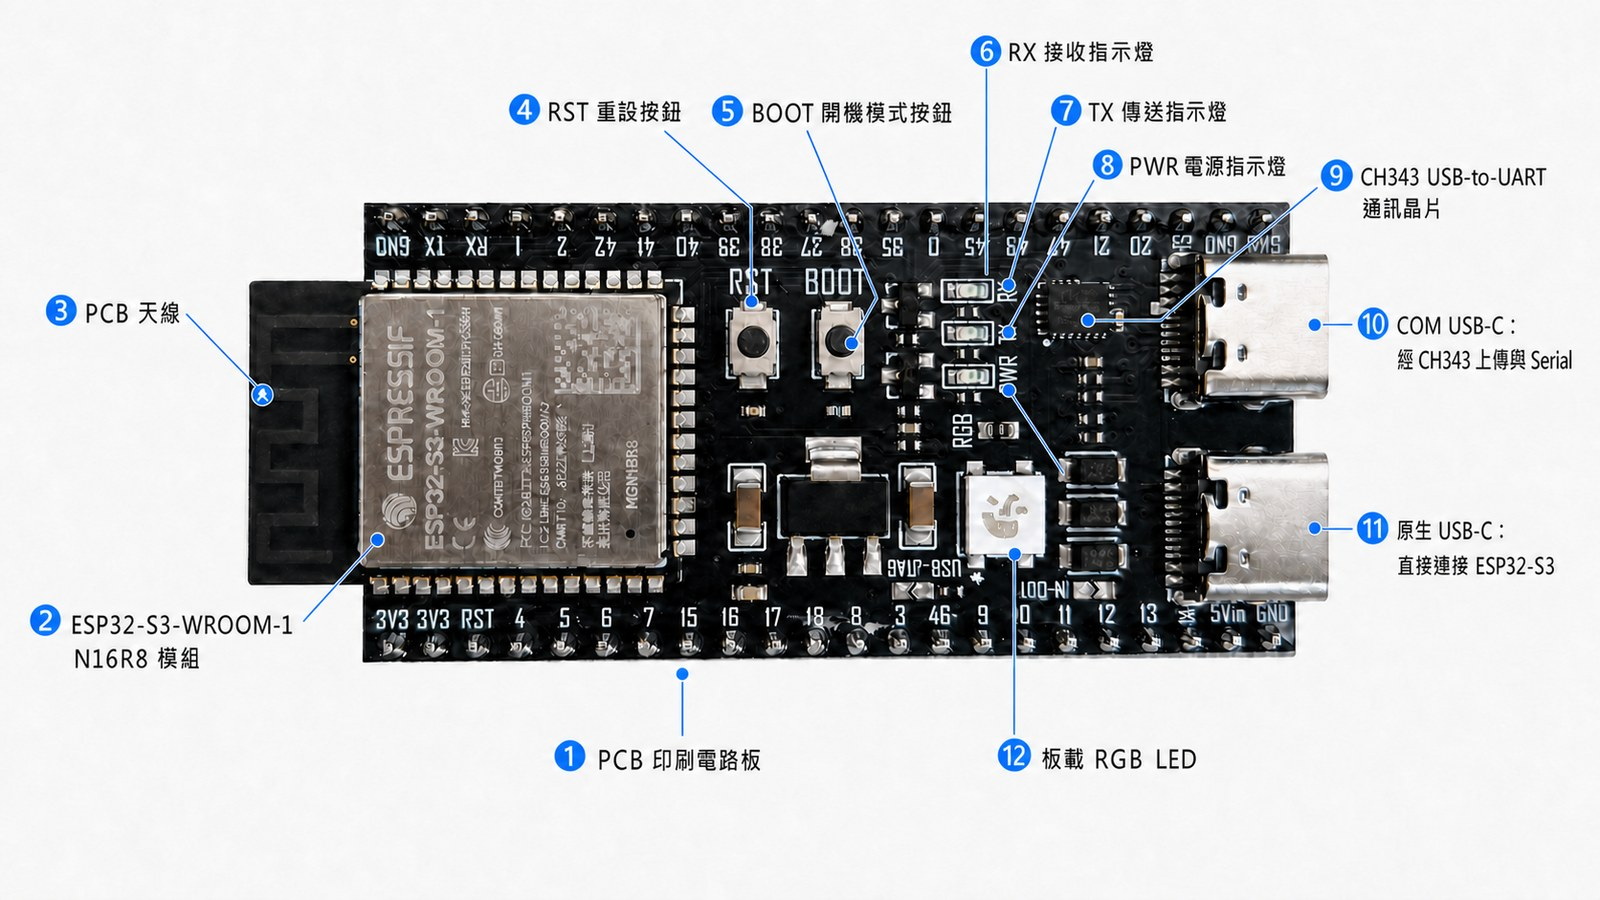

### 步驟4：分辨RST、BOOT與排針標示

| 標示 | 類型 | 本週用途 |
|---|---|---|
| `RST`／`RESET` | 控制按鈕 | 重新啟動目前Flash中的程式；不會刪除程式 |
| `BOOT` | 控制按鈕 | 上傳無法自動連線時，配合RST進入下載模式 |
| `4`、`5`等數字 | GPIO絲印 | 由程式設定為輸入或輸出；數字不是電壓 |
| `GND`／`G` | 0V參考 | 提供電壓基準與返回路徑；不是負電源 |
| `3V3` | 3.3V電源 | 本週辨認但不接到麵包板 |
| `5Vin` | 約5V電源路徑 | 本週不使用，也不是`5Yin`或GPIO5 |
| `TX`／`RX` | 序列通訊 | 表示資料傳送與接收活動 |

正常Upload通常由CH343自動控制下載與Reset，不需先按BOOT。只有Upload停在
`Connecting...`且已確認Board、Port與資料線後，才使用後面的手動BOOT／RST流程。

### GPIO、GND與3.3V的關係

電腦USB提供約5V，開發板穩壓電路將它轉成ESP32-S3使用的約3.3V。接上USB只會
讓晶片取得工作電力，不會使每支GPIO自動輸出3.3V；GPIO行為由程式設定。

```text
電腦USB約5V → 開發板穩壓電路 → 約3.3V電源軌 → ESP32-S3
```

本週把按鈕腳設為`INPUT_PULLUP`。**上拉電阻**是晶片內部從GPIO通往3.3V的
弱連接，讓未按按鈕時有明確的HIGH。按下時，按鈕把GPIO接到GND，輸入變成LOW。
上拉電阻同時限制流向GND的電流，因此這個輸入接法不是3.3V直接短路GND。

```text
放開：3.3V ──[內部上拉電阻]── GPIO ──[按鈕開路]── GND  → HIGH
按住：3.3V ──[內部上拉電阻]── GPIO ──[按鈕閉合]── GND  → LOW
```

**閉合電路**是電流能從電源出發、通過元件並返回電源的完整路徑；**開路**表示
其中一處中斷。閉合電路不等於短路：正常路徑具有負載或電阻，短路則是不同電位
間出現不預期的低阻抗捷徑。

一片開發板可能提供多個GND排針，方便不同位置接線；它們通常屬於同一GND網路。
本週只接一條GND線，再由麵包板的TPG列分接，不需要同時接兩個GND。

依實物完成辨認：

| 項目 | 板身實際標示或位置 |
|---|---|
| PCB與模組型號 |  |
| `COM` USB接頭 |  |
| BOOT與RST |  |
| 教師公布的`PIN_BUTTON` |  |
| 教師公布的`PIN_TEST_OUTPUT` |  |
| 使用的GND |  |

若實物絲印或外形與教材不同，停止接線並請教師核對，不依相似板卡圖片猜測。


## 五、Arduino IDE板卡與連接埠設定

### 步驟1：建立USB連線

本週使用板背標示`COM`的USB-C接頭。這條路徑經過**CH343 USB-to-UART**晶片，
把筆電USB資料轉成ESP32的UART序列通訊；CH343不執行Arduino程式，程式仍由
ESP32-S3執行。另一個標示`USB`的接頭是原生USB路徑，本週不使用。

1. 確認開發板沒有接麵包板、杜邦線或外部電池，放在乾燥、不導電的桌面。
2. 翻到背面讀取`COM`與`USB`絲印，不能只靠上下位置記憶。
3. 將可傳輸資料的USB線接到`COM`接頭，再直接接到筆電USB孔。
4. 等待Windows辨識裝置。`PWR`燈亮只證明有供電，尚未證明資料通訊成功。

```text
Upload：筆電USB → CH343 → UART → ESP32-S3
Serial：ESP32-S3 → UART → CH343 → 筆電USB → Serial Monitor
```

### 步驟2：選擇Board與N16R8設定

`ESP32S3 Dev Module`是Arduino IDE的通用編譯設定，不是實物PCB型號。`N16R8`
表示模組具有16 MB Flash與8 MB PSRAM；Flash斷電後仍保存程式，PSRAM是程式
執行時使用、斷電後不保留內容的額外記憶體。

使用 **Tools → Board → esp32 → ESP32S3 Dev Module**，再逐項核對：

| Tools設定 | 本課N16R8設定 | 作用 |
|---|---|---|
| Board | `ESP32S3 Dev Module` | 使用ESP32-S3編譯規則 |
| Flash Mode | `QIO 80MHz`或選單中的QIO | 符合本模組Flash介面 |
| Flash Size | `16MB (128Mb)` | 對應N16；8 bits等於1 byte |
| PSRAM | `OPI PSRAM` | 對應R8的Octal PSRAM |
| USB CDC On Boot | `Disabled` | 本週使用CH343 USB-to-UART |
| Upload Mode | `UART0 / Hardware CDC` | 使用UART下載路徑 |
| Upload Speed | `115200` | 本課已驗證的上傳速度 |
| Erase All Flash Before Sketch Upload | `Disabled` | 一般上傳不清除整顆Flash |

`Partition Scheme`依教師公布、且與課堂Arduino-ESP32版本相同的設定。選單名稱若
與教材不一致，不自行挑選看起來較快或容量較大的選項，先保存畫面並請教師核對。

本課實物、IDE設定與程式讀值是不同層次：

```text
IDE Board：ESP32S3 Dev Module
實際PCB：YD-ESP32-S3 Type-A V1.5
實際模組：ESP32-S3-WROOM-1 N16R8
實際晶片：ESP32-S3
```

官方參考：[ESP32-S3-WROOM-1資料表](https://documentation.espressif.com/esp32-s3-wroom-1_wroom-1u_datasheet_en.pdf)｜[Arduino-ESP32 Tools Menu](https://docs.espressif.com/projects/arduino-esp32/en/latest/guides/tools_menu.html)

### 步驟3：用拔除前後比較找Port

**Port**是IDE與目前連接裝置通訊的入口。Windows的`COM8`等號碼會依電腦與USB孔
改變，不能照抄別人的號碼。萬用電表上的`COM`則是黑表筆插孔，兩者沒有關係。

1. 先拔除ESP32 USB，開啟 **Tools → Port**並記下現有清單。
2. 關閉選單，把ESP32接回同一個USB孔，等待Windows辨識。
3. 再開 **Tools → Port**，找出新出現的Port並選取。
4. 這批板卡可能顯示`USB-Enhanced-SERIAL CH343`，也可能只顯示COM號碼；以
   拔除前後差異為判斷，不選Bluetooth Port。

我的Port：`____________________`

沒有新Port時，依序更換已知可傳資料的USB線、筆電USB孔，再重新開啟Port選單。
仍無法辨認時保存裝置管理員畫面，不安裝來源不明的driver。

### 本節檢核

- [ ] 使用板背標示`COM`的USB接頭。
- [ ] Board為`ESP32S3 Dev Module`，Flash Size為16 MB，PSRAM為OPI。
- [ ] Upload Speed與Serial Monitor均使用115200；兩者是不同階段的設定。
- [ ] 已用拔除前後比較找到自己的Port。


## 六、第一個程式：編譯、上傳與序列輸出

### 步驟 1：建立程式

- **Sketch** 是 Arduino 對一個程式專案的稱呼，資料夾和主要 `.ino` 檔通常
  使用同一名稱。
- **`setup()`** 在開機或 RESET 後只執行一次；**`loop()`** 會在之後持續
  重複執行。
- `CHANGE_ME` 和 `XX` 是「請換成自己的資料」的預留文字，不是固定答案。
- **baud rate** 是序列通訊速度。本課程式使用 115200，稍後 Serial Monitor
  也必須選相同數值。

1. 點 **File → New Sketch**。
2. 點 **File → Save As**。
3. 將資料夾／Sketch 名稱設為 `week02_serial_groupXX`，把 `XX` 換成組別。
4. 刪除編輯器內原本的 `setup()` 與 `loop()` 範本，避免重複定義。
5. 使用 GitHub 程式區塊右上角的 Copy 按鈕，完整複製下列程式。
6. 貼到 Arduino IDE。
7. 把 `CHANGE_ME` 改成組別，例如第 3 組改成 `03`。
8. 按 **Ctrl+S** 儲存。

#### 程式語法說明

- `unsigned long` 是可保存非負整數的資料型別，本程式用來保存毫秒時間。
- `millis()` 取得 ESP32 從開機到目前經過的毫秒數。
- `if` 表示只有括號內條件成立，才執行大括號內的程式；`>= 1000` 表示已經
  過了至少 1000 毫秒。
- `Serial.begin(115200)` 以 115200 baud 啟動序列通訊。
- `Serial.println()` 輸出一整行文字；`Serial.printf()` 可把變數插入文字，
  `%lu` 對應 `unsigned long`，`\n` 表示換行。

完整程式：


In [ ]:
unsigned long lastReportMs = 0;

void setup() {
  Serial.begin(115200);
  delay(500);
  Serial.println("boot: week02 group=CHANGE_ME version=1");
}

void loop() {
  unsigned long now = millis();

  if (now - lastReportMs >= 1000) {
    lastReportMs = now;
    Serial.printf("status: uptime_ms=%lu\n", now);
  }
}


baud rate 維持 115200。貼上後確認程式只出現一組 `setup()` 與一組 `loop()`。

### 步驟 2：分辨 Verify 與 Upload

- **Verify／Compile（驗證／編譯）**：檢查語法，再把人寫的程式轉成 ESP32
  可執行的韌體；成功不代表已經寫進板子。
- **韌體（firmware）**：儲存在 ESP32 Flash、開機後會執行的程式。
- **Upload（上傳／燒錄）**：把編譯完成的韌體寫入板子。
- **Output**：IDE 下方顯示編譯和上傳過程的區域，不是稍後顯示程式文字的
  Serial Monitor。

1. 點左上角勾號 **Verify**。
2. 檢查視窗下方 Output 的文字，不以進度動畫作為成功判斷。
3. 等待編譯完成及記憶體用量訊息；若出現紅色錯誤，應先處理 Output 中最早
   出現的錯誤，不從最後一行反向推測。
4. Verify 成功後，點右箭頭 **Upload**。
5. Output 會先再次編譯，再出現連線、寫入百分比及完成訊息。
6. 等待 `Hard resetting via RTS pin...` 或 IDE 顯示 Upload 完成。
7. Upload 期間不得拔線、按 RESET 或移動板子。

`Hard resetting via RTS pin...` 通常表示 IDE 已透過 USB-to-UART 的 RTS 控制
訊號自動重設板子，讓新程式開始執行；它不是「硬體損壞」訊息。

Verify成功時常見的記憶體摘要可以這樣判讀：

```text
Sketch uses ... bytes (...) of program storage space.
Maximum is ... bytes.
Global variables use ... bytes (...) of dynamic memory.
```

- `Sketch uses`是本次韌體占用的程式分割區空間。
- `Maximum`是目前Partition Scheme分給應用程式的上限，不是整顆Flash容量；
  16 MB Flash中的其他區域可能分給檔案系統、系統資料或其他映像。
- `Global variables`是編譯時可計算的內部記憶體配置，不能用來證明8 MB PSRAM
  已經啟用；PSRAM仍須由程式執行期間的runtime讀值確認。

Upload時的`Writing at ... 100%`表示資料已傳送到Flash；`Hash of data verified`
表示寫入後資料與本次傳送內容的雜湊比對相符。這些訊息證明寫入流程完成，
仍不能證明程式功能、GPIO或外接硬體正確。`Sketch uses`與`Wrote`的bytes可能因
映像區段、對齊或傳輸格式而不同，不必強求兩個數字相同。

Verify 成功不等於 Upload 成功；Upload 成功也不等於程式功能正確。三者需要
不同證據。

#### `Connecting...` 停滯時的處理

`Connecting...` 表示 IDE 正嘗試和 ESP32 建立下載連線。BOOT 可讓板子進入
下載模式，RESET 讓板子重新啟動；只有正常自動 Upload 失敗時才使用下列
手動順序。

依下列順序做一次手動下載模式：

1. 保持 USB 連接。
2. 按住板上的 **BOOT** 不放。
3. 短按一下 **RESET／RST** 後放開 RESET。
4. 再放開 BOOT。
5. 回到 Arduino IDE，重新確認 Port。
6. 再按 Upload。

另一種常見操作是先按 Upload，看到 `Connecting...` 時按住 BOOT，連線開始
寫入後再放開。兩種方式都只在正常自動 Upload 失敗時使用。

若 Output 顯示晶片不是 ESP32-S3，應立即停止並回到 Board 設定，不得使用
錯誤 Board 強行上傳。

### 步驟 3：檢查 Serial Monitor 輸出

- **Serial** 是 ESP32 與電腦依序傳送文字或資料的通訊方式。
- **Serial Monitor** 是 Arduino IDE 顯示這些程式輸出的視窗。
- **log** 是程式留下的執行紀錄，例如組別、版本、事件與時間。
- **115200 baud** 是本程式的傳輸速度；程式與 Serial Monitor 設定不同時，
  文字可能變成亂碼。

Serial Monitor不會自動掃描晶片或顯示「所有硬體參數」。它只顯示程式透過
`Serial.print()`、`Serial.println()`或`Serial.printf()`主動送出的內容。
`Serial.begin(115200)`設定ESP32送出序列資料的速度，Monitor也必須選115200；
Upload Speed即使也是115200，仍屬於「電腦把韌體送到板子」的另一個階段。

1. Upload 完成後，點 Arduino IDE 右上角 **Serial Monitor** 圖示，或選
   **Tools → Serial Monitor**。
2. 在 Serial Monitor 的 baud rate 選單選擇 `115200`。
3. 按一下板上的 RESET，讓開機訊息重新出現。
4. Serial 輸入框保持空白；本程式不讀取鍵盤輸入。
5. 預期看到：

```text
boot: week02 group=03 version=1
status: uptime_ms=1000
status: uptime_ms=2000
status: uptime_ms=3000
```

`boot: ...`是程式自己寫出的開機訊息，不是ESP32內建健康報告。`uptime_ms`來自
`millis()`，表示本次開機或Reset後經過的毫秒數；增加約1000代表約一秒。按RST
後再次看到`boot: ...`，且uptime重新從接近0開始，才形成「程式已重新啟動」的
可觀察證據。若Serial Monitor在`setup()`完成後才開啟，可能先只看到uptime；
短按RST可以重現開機訊息。Monitor保留的Reset前舊文字不代表兩份程式同時執行。

若是亂碼：

1. 確認 baud rate 是 115200。
2. 確認 Serial Monitor 使用的 Port 和 Upload 的 Port 相同。
3. 按 RESET 再看一次。

若完全沒有文字：

1. 關閉 Serial Monitor。
2. 重新確認 Tools → Port。
3. 再開 Serial Monitor 並選 115200。
4. 按 RESET。
5. 檢查程式是否包含 `Serial.begin(115200)`。
6. 仍無輸出時重新 Upload，保存 Output 及 Serial 畫面再求助。

### 步驟 4：驗證程式版本

1. 關閉 Serial Monitor。
2. 在程式中把 `version=1` 改成 `version=2`。
3. 按 Ctrl+S。
4. 再按 Upload。
5. Upload 完成後重新開啟 Serial Monitor，確認 115200。
6. 按 RESET。
7. Serial 必須出現正確組別及 `version=2`。
8. 保存包含組別、版本與 uptime 的畫面，命名
   `week02_serial_version2_組別.png`。

### 本節檢核

- [ ] Verify 成功。
- [ ] Upload 成功。
- [ ] Serial 顯示正確組別與 `version=2`。
- [ ] 實驗紀錄已各用一句文字記錄 Verify 與 Upload 的用途。


## 七、麵包板與按鈕接線

### 步驟 1：斷開 USB 電源

1. 關閉 Serial Monitor。
2. 從 ESP32 端拔除 USB 線。
3. 確認板上電源燈熄滅。
4. 等待數秒後，再拿出麵包板、按鈕與杜邦線。

後面凡是寫「拔除 USB」，都要做到電源燈熄滅。只關閉 Serial Monitor 或只
停止程式，都不等於斷電。

### 步驟 2：確認麵包板導通結構

**麵包板（solderless breadboard）**是不必焊接就能暫時接線的實驗板。方孔
只是讓導線或元件腳進入；真正建立連接的是塑膠外殼下方的金屬彈片。新麵包板
第一次插線可能較緊，應捏住靠近金屬針的黑色接頭，讓公針垂直進孔並穩定下壓。
公針若開始彎曲就停止，不使用鉗子硬壓，也不把較粗的萬用電表表筆插進孔內。

本課實物是有`a～j`及`1～30`座標、左右各有紅藍電源軌的400孔麵包板：

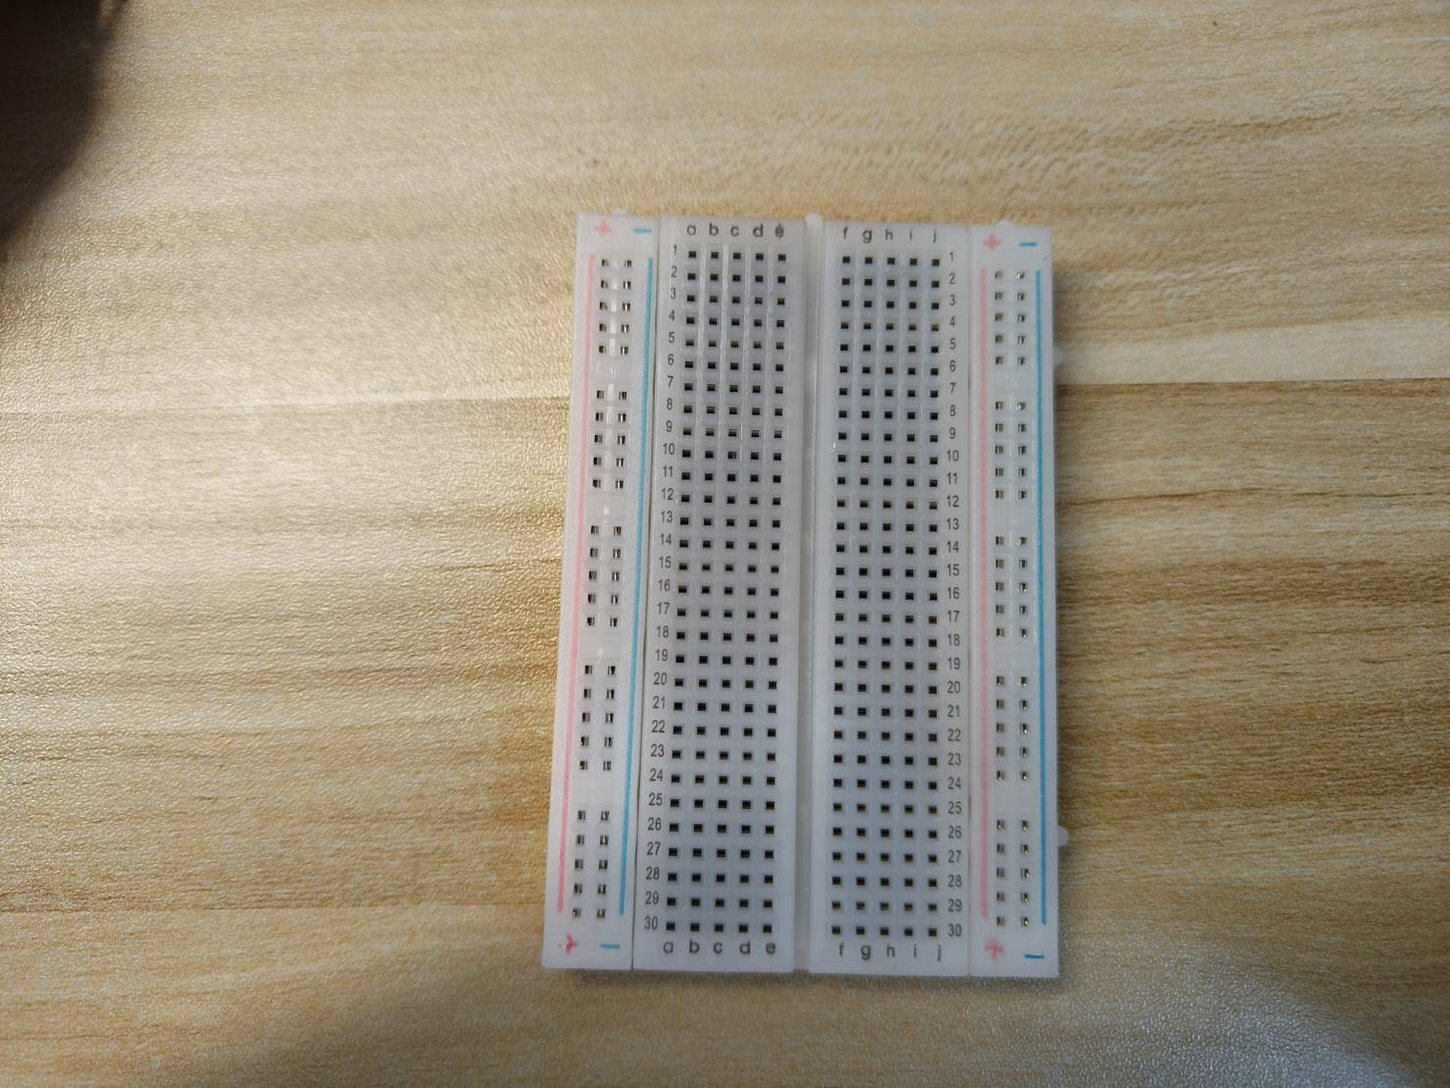

本課杜邦線實物包含公對公、公對母與母對母。插入麵包板時要使用有裸露金屬
公針的一端；顏色只協助整理線路，不會改變電氣功能。

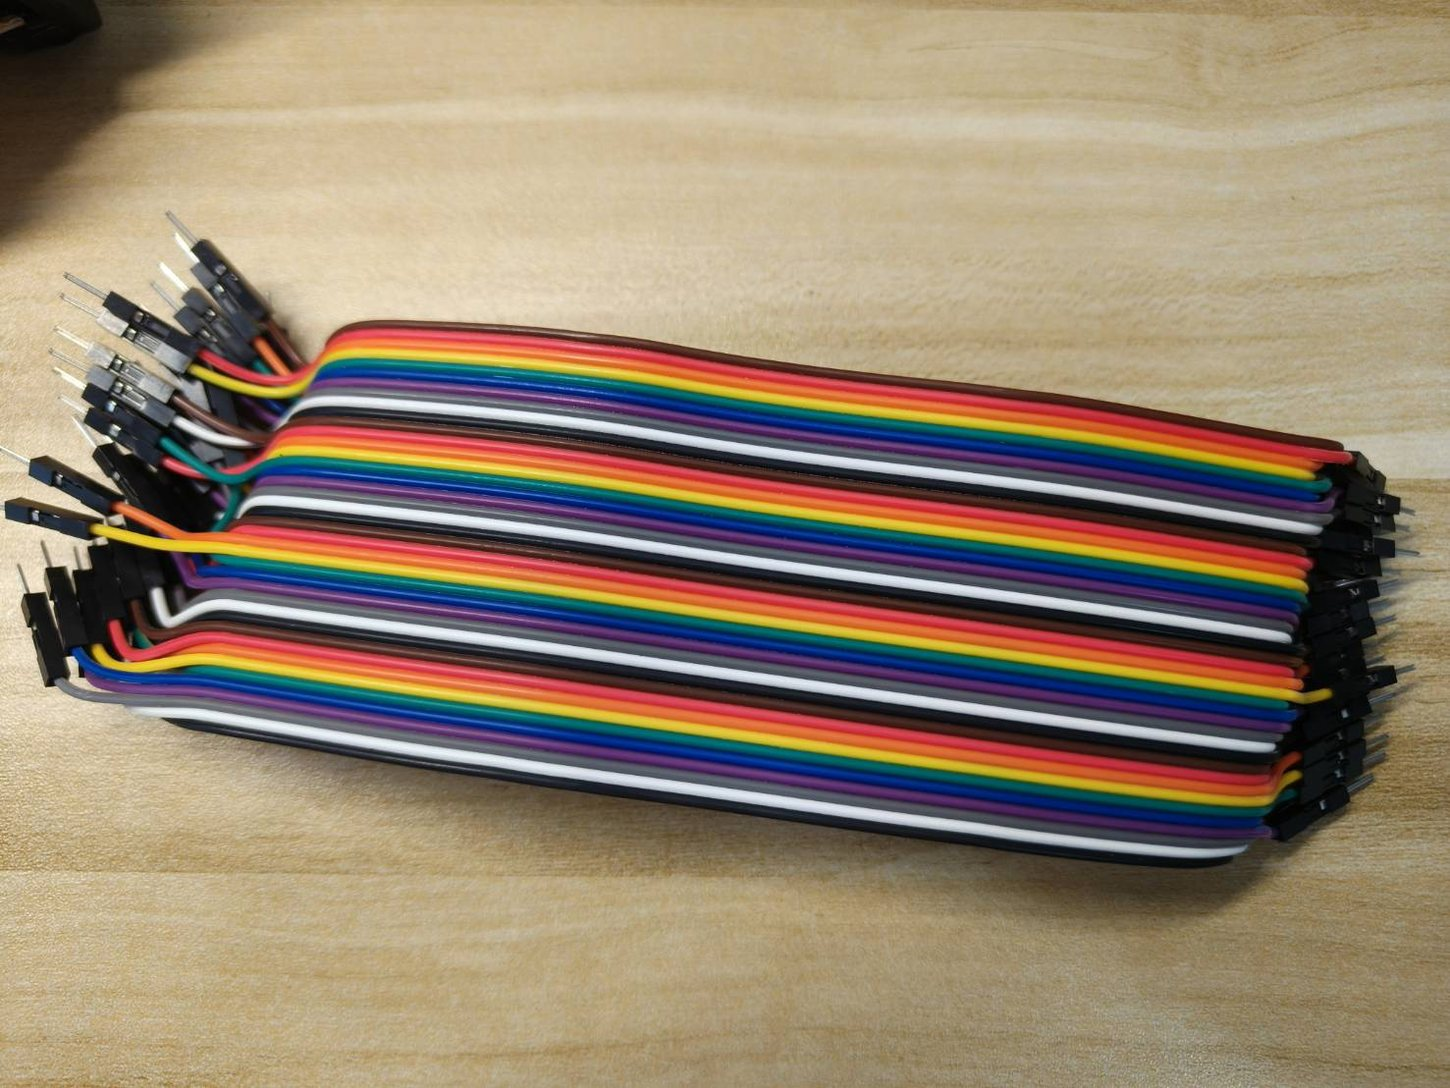

#### 中央實驗區的座標與五孔組

把麵包板直放、列號由上往下增加時，同一列可畫成：

```text
a10—b10—c10—d10—e10   │   f10—g10—h10—i10—j10
       左側五孔組       │          右側五孔組
                        │
                     中央溝槽
```

- `a10～e10`由同一片金屬彈片連接。
- `f10～j10`是另一片獨立金屬彈片。
- `e10`與`f10`雖然列號相同，仍被中央溝槽隔開。
- `a10`與`a11`雖然上下相鄰，仍屬不同列，不會自動連接。

這表示插在同一五孔組中的零件腳在電氣上屬於同一個**節點（node）**。例如兩支
零件腳同時插在`a10`與`b10`，並不是形成兩段串聯電路，而是把兩支腳直接接在
同一節點。

#### 斷電實測麵包板內部結構

下列測試使用兩條公對公杜邦線延伸測點。ESP32、USB及電池必須全部斷開；黑表筆
留在`COM`、紅表筆留在`VΩmA`，旋鈕使用聲波符號的通斷檔。先短接兩支表筆確認
會蜂鳴，再將杜邦線公針垂直插入指定孔，表筆只碰另一端外露的金屬針。

| 實際測點 | 本批實物測得 | 可以支持的判斷 |
|---|---|---|
| `a10`與`b10` | 有聲音 | 同列、同側的相鄰孔導通 |
| `a10`與`e10` | 有聲音 | 左側同一列的五孔組從`a`到`e`導通 |
| `a10`與`f10` | 沒聲音 | 中央溝槽兩側不相通 |
| `a10`與`a11` | 沒聲音 | 不同列不相通 |
| 左側紅色軌最上方與最下方 | 有聲音 | 這片實物的左紅色軌全長導通 |
| 左側紅色軌與左側藍色軌 | 沒聲音 | 左紅、左藍為兩條獨立路徑 |
| 左側紅色軌與右側紅色軌 | 沒聲音 | 左右兩條紅色軌獨立；同色不代表已連接 |

蜂鳴表示電表偵測到低於內部門檻的低阻抗路徑，不表示電阻一定恰好是`0.0Ω`。
沒聲音表示目前測點之間沒有低阻抗連接；先檢查公針、孔位及表筆接觸後，才能
把結果判為麵包板內部獨立。這些結果只適用於本次實物；其他麵包板仍要實測。

#### 紅色`+`、藍色`−`與GND

邊緣紅藍長列稱為**電源軌（power rail）**。紅線、藍線、`+`與`−`都只是印在
塑膠上的接線慣例，不是電源：沒有接USB、電池或電源供應器時，兩條軌都不會
自行產生電壓。

| 實際接法 | 紅色軌的電氣狀態 | 藍色軌的電氣狀態 |
|---|---|---|
| 兩條都沒有接電源 | 未供電 | 未供電 |
| 紅色接ESP32 `3V3`、藍色接`GND` | 相對GND為約+3.3V | 0V參考點／GND |
| 紅色接`5Vin`、藍色接`GND` | 相對GND為約+5V | 0V參考點／GND |
| 顏色接反 | 可能實際成為GND | 可能實際成為正電源；容易誤接，不採用 |

**電壓（voltage）**是兩點之間的電位差。**GND（ground）**是電路選定的0V
共同參考點，不是「裝滿負電」的地方。單一正電源系統通常把電源負端接到GND，
所以藍色`−`軌常被用作GND；這是接線選擇，不是藍色印刷自動造成。若使用正負
雙電源，`−5V`可能低於GND，此時負電源與GND就不是同一個節點。

可以用樓層理解相對關係：GND像定義為0樓的地面，`3V3`像高出3.3V的位置，
`−5V`則像低於地面的地下樓層。選定地面後才能描述其他位置比它高或低。

本週這一段只做斷電通斷測試，不把紅藍軌接到`3V3`、`5Vin`或GND。稍後的GPIO
核心線路直接建立TPO與TPG測點，不依賴電源軌；這可以減少初學階段誤接電源的
機會。

**TP** 是 Test Point（測試點）的縮寫。`TPO`和`TPG`不是麵包板原廠名稱，
而是本實驗定義的標籤：TPO接profile指定的測試輸出，TPG接GND。

先用筆或可移除標籤在板邊寫下：

```text
左外側接線欄：A
右外側接線欄：J
TPO 預留列：________
TPG 預留列：________
```

TPO 與 TPG 必須是兩個不同的空白列，而且不能位於 ESP32 排針占用的列。

### 步驟 3：確認四腳按鈕結構

本課按鈕是**常開瞬時按鈕（normally open momentary pushbutton）**：平常
兩組接點彼此不導通，只有按住時兩組才導通，放開後立即恢復。**導通**表示
兩點之間有可通過測試電流的低阻抗路徑；**開路／不導通**表示路徑中斷。

四支腳不是四個完全獨立的接點。按鈕內部先把兩腳連成A組，另外兩腳連成B組：

```text
A1 ●────● A2       未按：A組與B組分開
        [按鈕]      按住：A組與B組接通
B1 ●────● B2       放開：A組與B組再次分開
```

外觀看見的左、右、上、下不能直接當作固定答案；元件方向改變後，畫面上的位置
也會改變。必須用通斷檔找出哪兩腳原本就是同一組，再選A組的一腳與B組的一腳
作為開關兩端。

本課實物跨在中央溝槽、四腳位於`E27`、`F27`、`E29`、`F29`時，2026-08-29
實測如下：

| 測點 | 未按按鈕 | 判讀 |
|---|---|---|
| `a27`與`j27` | 有聲音 | 第27列兩腳是內部原本相通的同一組 |
| `a27`與`j29` | 沒聲音 | 第27列與第29列是不同組 |
| `a27`與`j29`，按住按鈕 | 有聲音 | 按下後兩組接通 |
| `a27`與`j29`，再次放開 | 沒聲音 | 瞬時按鈕已恢復開路 |

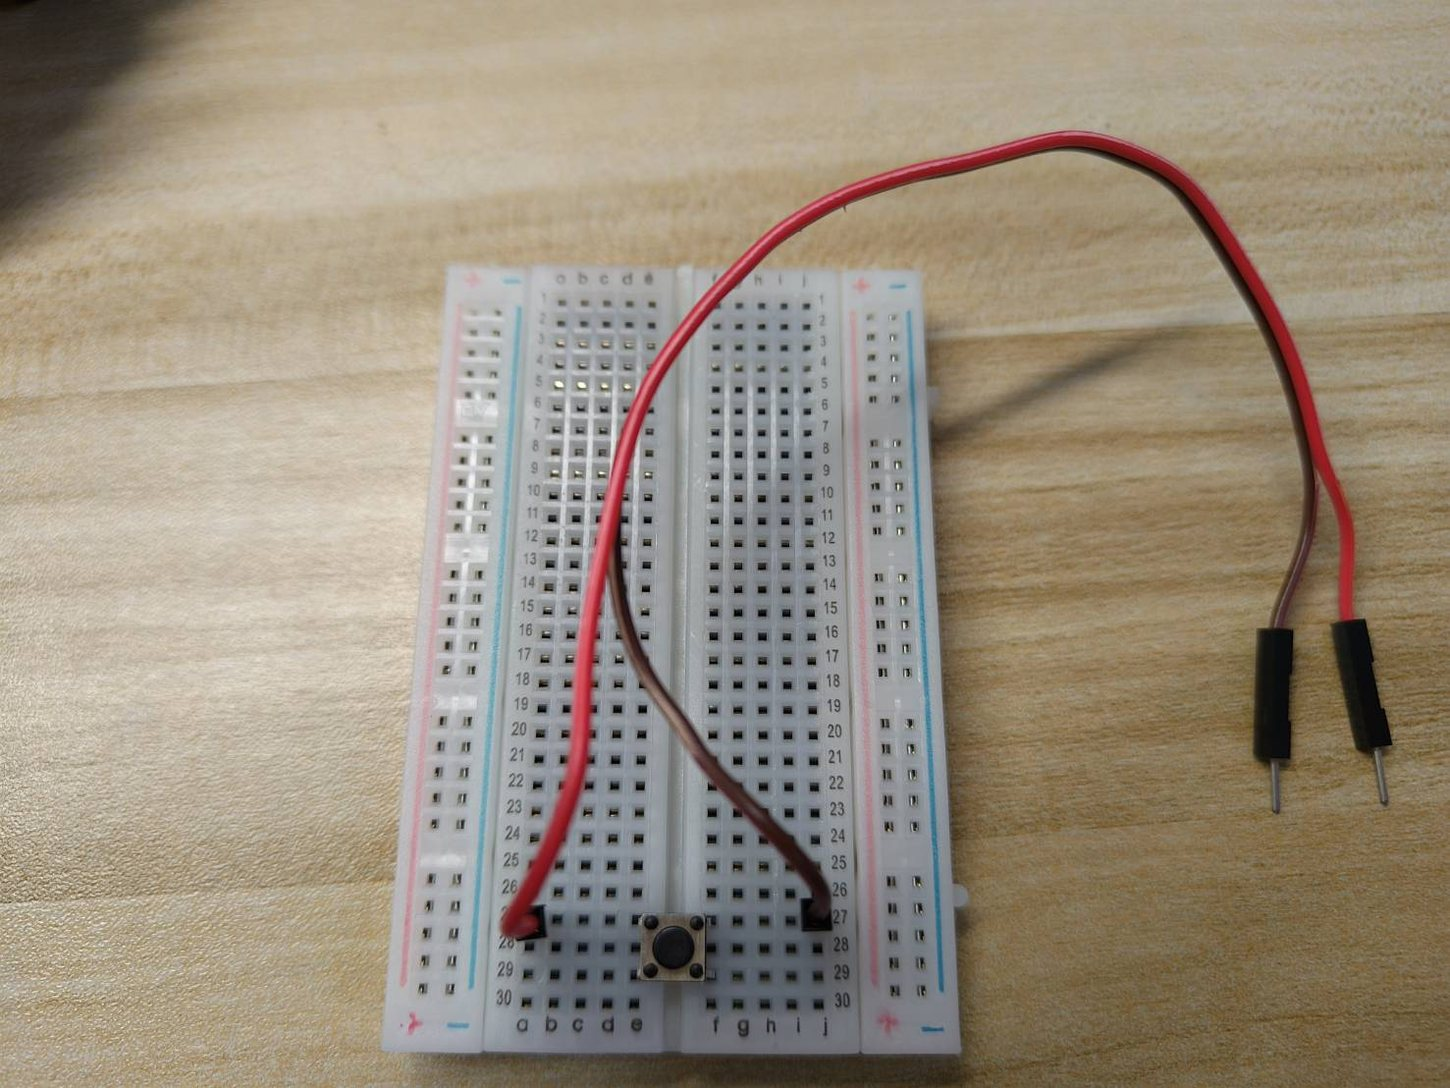

第一次用`a27`與`j27`測到蜂鳴不是按鈕損壞，也不是電源短路；兩點只是被按鈕
內部的固定金屬接點連在同一組。把其中一個測點改到第29列後，才能觀察按下與
放開造成的狀態變化。這項結論只適用於已量測的實物與方向；換按鈕或旋轉方向
後要重新確認。

先將按鈕放在桌上觀察並規劃位置：

1. 選兩個相隔約兩列的空白位置，例如第27與第29列。
2. 預定讓四腳進入`E27`、`F27`、`E29`、`F29`，使本體跨在中央溝槽上。
3. 四支腳必須自然對孔，不得扳到明顯變形。
4. 插入後再用通斷檔確認實物的兩組接點，不能只靠外觀猜測。

若實物腳距不同，列號可以改，但必須同時滿足「跨槽」、「四腳自然對孔」與
「通斷量測已找出兩組接點」。

### 步驟 4：用實物確認開發板與麵包板尺寸

**排針（pin header）**是開發板兩側向下的金屬接腳。是否能直接安裝，必須看
排針實際進入哪一欄，不能用開發板黑色PCB邊緣推測。

本批YD板與400孔麵包板在斷電狀態下實際對孔，結果是：

```text
中央實驗區： A  B  C  D  E  │  F  G  H  I  J
                 ▲                         ▲
              左排排針                  右排排針

左排：B3～B24，共22腳
右排：J3～J24，共22腳
```

第3列到第24列包含22個孔位，與開發板左右各22腳、合計44腳相符。這也修正了
先前尚未以實物驗證的`B/I`假設：本批YD板右排實際落在`J`，不是`I`。

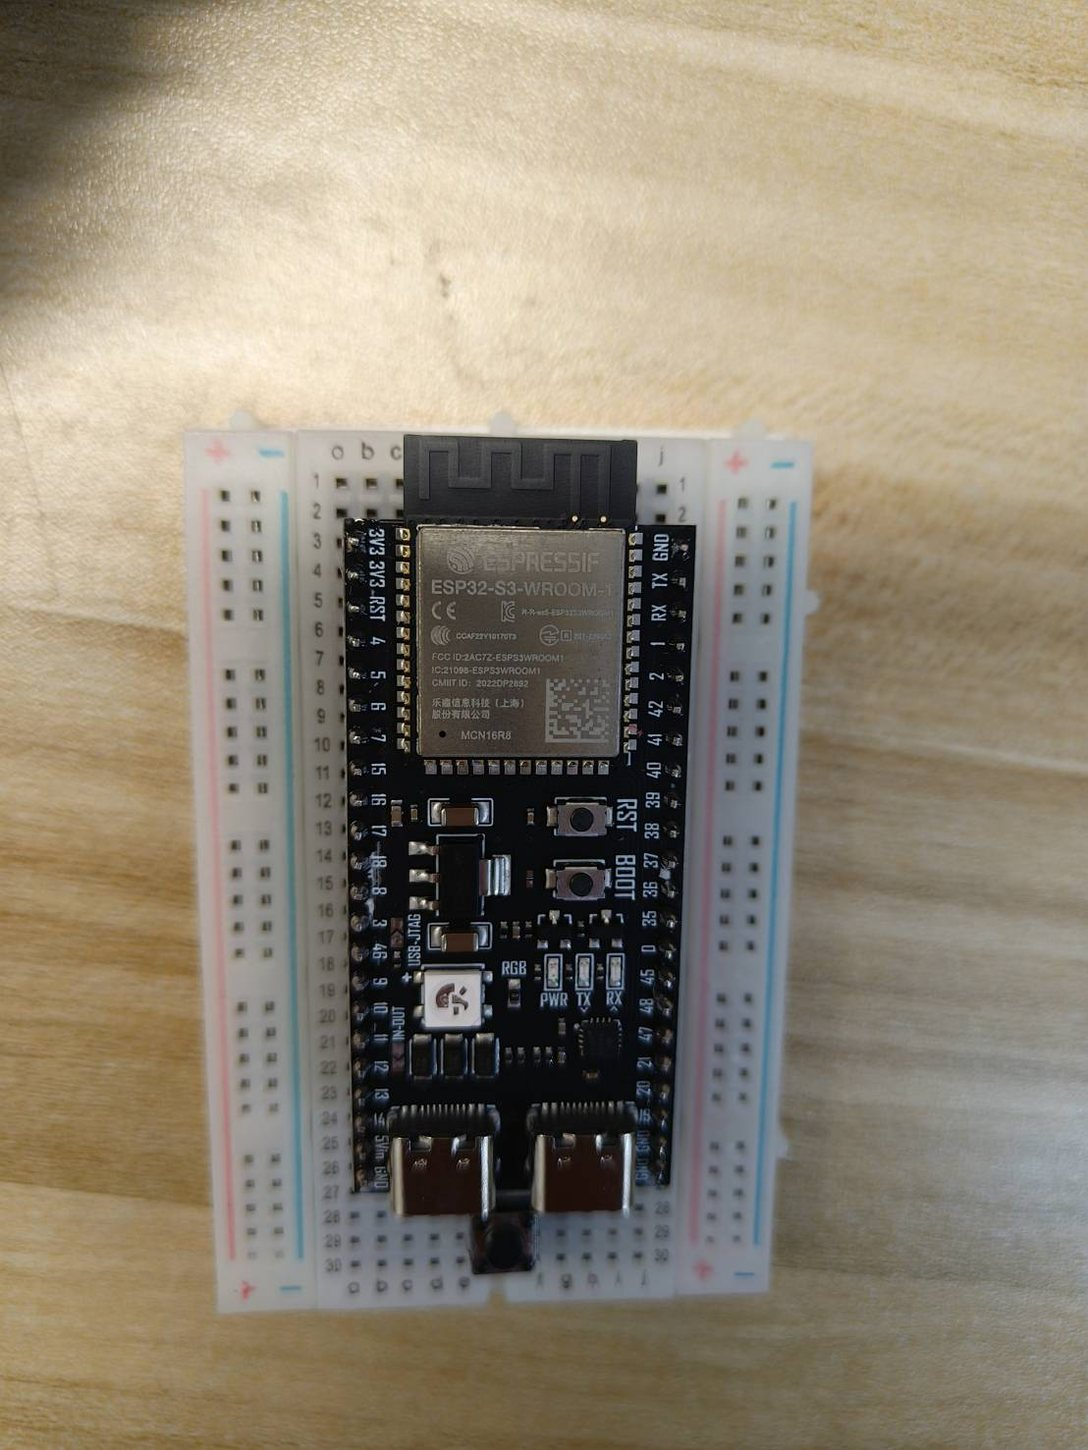

這個位置只在左側留下`A`欄，右側`J`欄已被排針占用；右排GPIO沒有同一列的
空孔可接杜邦線。開發板USB端也遮住第27與第29列的外接按鈕。因此本課不把
BOARD-T01直接壓入單片400孔麵包板，也不要求學生購買另一種麵包板；改用已在
必買清單內的公對母杜邦線進行板外連接。

若板子只是懸在孔上，直接垂直拿起。若已壓入：

1. 確認USB、電池與所有其他電源都已拔除。
2. 不拉天線、USB接頭、BOOT或RST按鈕。
3. 兩手捏住PCB兩端的板邊，先把一端抬高約1～2 mm，再換另一端抬高相同距離。
4. 兩端交替、小幅度向上移動，使兩排排針大致平行退出；不可一次把一端大幅
   翹起，也不可用金屬螺絲起子撬板。
5. 取下後檢查44支排針是否仍平行；發現彎針就停止，不自行帶電測試。

### 步驟 5：採用板外公對母杜邦線

**公對母杜邦線（male-to-female jumper wire）**一端是可套在開發板排針上的
母頭，另一端是可插入麵包板的公針。BOARD-T01放在麵包板旁的乾燥、不導電
平面，不讓排針碰到金屬；USB端保持可插拔，線材不能懸吊或拉扯板子。

本週的三條板對板連線都採以下形式：

```text
ESP32板身排針 ← 公對母線的母頭
公對母線的公針 → 麵包板指定五孔組
```

在教師完成GPIO target test並公布profile前，只辨認腳位，不接候選GPIO。公布後
才填寫並逐條連接：

| 訊號 | 板身絲印／profile | 杜邦線顏色 | 麵包板目的地 |
|---|---|---|---|
| 按鈕輸入 | `PIN_BUTTON`：_____ |  | `BTN-A`接點組 |
| 測試輸出 | `PIN_TEST_OUTPUT`：_____ |  | TPO獨立五孔組 |
| 地 | `G`／GND |  | TPG獨立五孔組 |

顏色只用來追蹤線路，不會自動決定正電、負電或GND。母頭必須套在已由絲印與
profile確認的單一排針，不能一次跨到相鄰兩腳；公針垂直插入麵包板，開始彎曲
就停止施力。

### 步驟 6：安裝按鈕

1. 再確認預定的四個孔沒有被 ESP32 或導線占用。
2. 讓按鈕跨過中央溝槽。
3. 四支腳全部對孔後，從按鈕本體正上方平均壓入。
4. 輕推按鈕；它應穩定留在板上，不應只有兩腳勉強插入。
5. 保持完全斷電，用兩條公對公杜邦線延伸測點；找出未按時原本導通的
   第一組並標成`BTN-A`，另一組標成`BTN-B`。
6. 在`BTN-A`與`BTN-B`各選一個測點：未按應不蜂鳴、按住應蜂鳴、放開應再次
   不蜂鳴。三個狀態都符合，才完成按鈕安裝。

### 步驟 7：完成實驗接線

下表是本批板卡的接線範例。GPIO編號必須以教師授課前公布的profile為準；線色只用於追蹤，不是所有組都必須相同。

| 順序 | 線材與顏色 | ESP32端 | 麵包板端 | 作用 |
|---|---|---|---|---|
| 1 | 棕色公對母 | 右排最上方`GND` | 公頭插`a22` | 建立TPG接地參考列 |
| 2 | 紅色公對母 | 左排候選`GPIO4` | 公頭插`a27` | 連到按鈕`BTN-A`接點組 |
| 3 | 橘色公對母 | 左排候選`GPIO5` | 公頭插`a20` | 建立TPO輸出量測列 |
| 4 | 另一條公對公，顏色另行記錄 | 一端插`b22` | 另一端插`a29` | 從同一TPG分接GND到按鈕`BTN-B`接點組 |

目前按鈕跨中央溝槽，左側兩腳位於`e27`與`e29`。同一列左半部`a`至`e`五孔彼此導通，因此`a27`會連到`e27`，`a29`會連到`e29`。`a20`至`e20`是TPO，`a22`至`e22`是TPG；第20列與第22列彼此不導通。右半部按鈕腳`f27`與`f29`本次不接線。

```text
左半部孔位        目前連接
a20─b20─c20─d20─e20   橘色GPIO5；TPO量測列
a22─b22─c22─d22─e22   棕色GND；b22再分接至a29
a27─b27─c27─d27─e27   紅色GPIO4；e27是按鈕一側
a29─b29─c29─d29─e29   來自TPG；e29是按鈕另一側
```

此接法不使用紅藍電源軌、`3V3`、`5Vin`或右排下方GND。插線期間ESP32必須保持USB斷開。三條公對母線的母頭只套住指定的單一排針，不能同時碰到相鄰排針。

一次只插一條線，每插完一條就在表中打勾：

1. [ ] `PIN_BUTTON`排針 → 公對母線 → 已量測確認的`BTN-A`接點組。
2. [ ] GND排針 → 公對母線 → 預留的TPG空白五孔組。
3. [ ] TPG同一五孔組的另一孔 → 公對公線 → 已量測確認的`BTN-B`接點組。
4. [ ] `PIN_TEST_OUTPUT`排針 → 公對母線 → 預留的TPO空白五孔組。

此接法只使用板上一個 GND：TPG 是共同接地列，再從 TPG 分接到按鈕。四條
杜邦線分別是`PIN_BUTTON→BTN-A`、`GND→TPG`、`TPG→BTN-B`、
`PIN_TEST_OUTPUT→TPO`。

本週的電氣關係必須是：



```text
ESP32 PIN_BUTTON ---- 按鈕的一側
ESP32 GND  --------- 按鈕的另一側
```

另外建立兩個安全量測點，不要直接用表筆在相鄰排針間探測：

```text
ESP32 PIN_TEST_OUTPUT -- 麵包板空白列（標記為 TPO）
ESP32 GND  --------- 麵包板另一空白列（標記為 TPG）
```

後面量電壓時，黑表筆接TPG，紅表筆接TPO，可降低表筆滑動造成短路的
風險。TPO只接`PIN_TEST_OUTPUT`與紅表筆，不接其他模組。

本接法在程式中使用 `INPUT_PULLUP`，不需要額外外接上拉電阻：

- 未按下：讀到 `HIGH`。
- 按下：`PIN_BUTTON`被接到GND，讀到`LOW`。

### 步驟 8：執行上電前接線檢查

不能只看接線「像不像圖片」，必須從訊號起點沿線檢查到終點：

1. 依profile指著`PIN_BUTTON`的板身絲印，確認母頭只套住該排針，再沿線
   走到按鈕`BTN-A`接點組。
2. 指著板身`G`／GND，確認母頭只套住GND排針，再沿線走到TPG，接著從TPG
   走到按鈕`BTN-B`接點組。
3. 依profile指著`PIN_TEST_OUTPUT`的板身絲印，確認母頭只套住該排針，再沿線
   走到標記TPO的獨立列。
4. 再從TPG反向沿線回到板身GND，確認沒有誤套相鄰排針。
5. 確認TPO與TPG不在同一個五孔導通組。
6. 確認沒有任何線接到 `5V`、`3V3` 或未使用的 GPIO。
7. 從正上方拍一張能看清板身絲印與線路終點的照片。

完成逐線檢查後，使用每組的萬用電表做兩項斷電測試：

1. 黑表筆接TPG，紅表筆接按鈕輸入列。放開按鈕時不應蜂鳴；按住時應蜂鳴；
   再次放開後應恢復不蜂鳴。
2. 黑表筆接TPG，紅表筆接TPO。此時不應蜂鳴；若持續蜂鳴，代表輸出測試列與
   GND之間存在低阻抗路徑，保持斷電並重新逐線檢查。

兩項都符合後，把萬用電表轉到`OFF`並移開表筆，再接回`COM` USB。觀察五秒：
`PWR`可亮起，但不得出現焦味、煙、異常聲音、明顯發熱或反覆重啟。異常時立即
拔除USB。若板內仍保存上一支程式，`TX`可能隨Serial傳送閃爍；燈號只作輔助，
不能取代後續Upload與Serial證據。

#### 為什麼第二項通斷測試可以偵測低阻抗短路？

萬用電表的通斷測試模式會使用電表內部電池，在兩支表筆之間施加很小的測試訊號，再判斷測得的路徑是否足夠低阻。不同電表的蜂鳴門檻可能不同，因此不能把『蜂鳴』解讀成電阻一定正好為0Ω；它代表目前量到低於該電表門檻的低阻抗通路。

本次黑表筆放在`c22`。`c22`與棕色GND線所在的`a22`屬於同一五孔組，因此黑表筆位於TPG／GND端。紅表筆放在`b20`；`b20`與橘色GPIO5線所在的`a20`屬於同一五孔組，因此紅表筆位於TPO／候選GPIO5端。量測等效關係是：

```text
紅表筆b20 ── TPO ── 橘色線 ── GPIO5
                                      ?
黑表筆c22 ── TPG ── 棕色線 ── GND
```

若接線錯誤使GPIO5與GND之間出現很低阻抗的直接通路，電表的小測試電流可以完成路徑並持續蜂鳴。此時若上電後再把GPIO5設定為HIGH，GPIO5會嘗試輸出接近3.3V，卻同時被低阻抗路徑拉到0V，可能造成過大電流。因此先在斷電狀態檢查，可在使用系統電源前找出這類錯接。

沒有蜂鳴只表示目前沒有量到低於蜂鳴門檻的GPIO5對GND通路。它不能證明GPIO5腳位選對、HIGH／LOW輸出正常、實際電壓正確，也不能排除高阻漏電、接觸不良或GPIO5與其他接腳之間的錯接。這些項目仍須以接線追蹤、上電程式、Serial輸出與直流電壓量測分別驗證。

### 上電前接線表

| 元件 | 元件腳位 | ESP32 腳位 | 方向／用途 |
|---|---|---|---|
| 按鈕 | `BTN-A`接點組 | `PIN_BUTTON`（填實際GPIO：_____） | 數位輸入 |
| 按鈕 | `BTN-B`接點組 | GND | 按下時接地 |
| TPO 測試列 | 空白麵包板列 | `PIN_TEST_OUTPUT`（填實際GPIO：_____） | HIGH／LOW 電壓測試 |
| TPG 參考列 | 另一空白列 | GND | 黑表筆參考點 |

身邊有同學時，請同學依照上述順序和你一起檢查。獨自操作時，先依第 1 至
第 5 項檢查一次，再從第 5 項反向檢查回第 1 項。確認兩次結果一致，而且沒有
任何線接到 5V，才能插回 USB。

### 本節檢核

- [ ] ESP32未直接插在單片400孔麵包板；排針筆直，板外位置穩定。
- [ ] 三條板對板連線使用公對母杜邦線，母頭各自只套住一支已確認排針。
- [ ] 按鈕四腳自然插入並跨過中央溝槽。
- [ ] 已用通斷檔找出`BTN-A`與`BTN-B`，並完成未按、按住、再次放開三態測試。
- [ ] `PIN_BUTTON`只經按鈕連到GND。
- [ ] `PIN_TEST_OUTPUT`只連到TPO。
- [ ] TPG連到GND，而且TPO、TPG不互通。
- [ ] 接線已依上述方式逐線確認；獨自操作時已完成正向與反向兩次檢查。


## 八、Profile按鈕輸入與測試輸出

### GPIO 與按鈕原理

- **輸入**是 GPIO 接收外部狀態；**輸出**是程式讓 GPIO 產生狀態。
- **HIGH／LOW** 是數位邏輯的兩種狀態。ESP32 的 HIGH 通常接近 3.3V、LOW
  接近 0V，但實際數值仍要用電表量測。
- **`INPUT_PULLUP`** 把 GPIO 設成輸入並啟用內部上拉電阻：按鈕未按時預設
  HIGH，按下接到 GND 時變成 LOW，因此本接法不需外加上拉電阻。
- **浮動**是輸入沒有被明確維持在 HIGH 或 LOW，可能把電氣雜訊誤認成按鈕
  動作；內部上拉可避免未按時浮動。
- **去抖（debounce／debouncing）**是正式技術術語，不是本課自創名稱。Arduino
  官方的[Debounce按鈕範例](https://docs.arduino.cc/built-in-examples/digital/Debounce/)會在
  輸入讀值改變時重新計時，只有讀值維持不變超過指定延遲後才更新按鈕狀態，
  目的是忽略短暫的noise（雜訊或非預期變化）。完整判斷可直接核對
  [Arduino官方`Debounce.ino`原始碼](https://github.com/arduino/arduino-examples/blob/main/examples/02.Digital/Debounce/Debounce.ino)。
- Arduino官方教材把按鈕在一次操作中產生多個短暫開／關脈衝的現象稱為
  **bouncing**；本課使用中文**接點彈跳**及英文`contact bounce／switch bounce`
  說明這個現象。`raw`與`stable`則是本課為了區分「立即讀值」與「已接受狀態」
  所使用的教學標籤，不是Arduino官方範例規定的欄位名稱。
- **去抖實驗**是本課比較不同去抖時間的活動名稱，不是一套全球統一的標準測試
  程序。本課會記錄板卡、按鈕、程式、操作次數與限制，讓結果可以重現。

### 步驟 1：上電前確認與 USB 復電

1. 確認階段 4 的接線檢查項目已全部通過。
2. 確認沒有人握著按鈕、杜邦線或萬用電表表筆。
3. 把 USB 接回原本測試成功的 USB-to-UART 接頭。
4. 觀察數秒；若出現發熱、異味或異常聲音，立刻拔除 USB。
5. 正常時只開 Arduino IDE，不要在上電後移動任何接線。

### 步驟 2：建立按鈕測試程式

`PIN_TEST_OUTPUT`本週不接LED、蜂鳴器、馬達或其他負載；本實驗先用Serial確認
程式已發出HIGH／LOW命令，實際輸出電壓移到Week 3以萬用電表驗證。**負載**是從電路取得能量的裝置，例如 LED、蜂鳴器
或馬達；GPIO 不適合直接供應高電流負載。

#### 程式結構

- `const int`建立不應改變的整數名稱，本程式用它替profile的兩個GPIO命名。
- `bool` 只保存 `true`／`false`，用來表示是否按下。


#### 先讀懂GPIO名稱與數字的對應

正式學生教材在profile完成驗證前使用安全placeholder：

```cpp
const int PIN_BUTTON = -1;
const int PIN_TEST_OUTPUT = -1;
```

`-1`在這裡是「尚未設定」的sentinel value（哨兵值），不是實際GPIO編號；程式的
`profileReady()`會因此阻止硬體功能啟動。教師目前另開候選測試檔，把
`PIN_BUTTON`暫時對應GPIO4、把`PIN_TEST_OUTPUT`暫時對應GPIO5進行BOARD-T01
target test。下列語法拆解使用候選按鈕設定中的GPIO4說明，但在所有實機檢查完成前，
主教材仍保留`-1`，不提前公布為學生固定答案。

候選檔的第一行可逐段閱讀：

| 程式部分 | 意思 | 本次對應 |
|---|---|---|
| `const` | 這個名稱建立後不應在程式執行途中改成別的數值 | 按鈕測試期間固定使用同一支GPIO |
| `int` | 儲存整數的資料型別 | GPIO編號以整數表示 |
| `PIN_BUTTON` | 程式自訂、可讀的名稱 | 看到名稱便知道它負責按鈕輸入 |
| `=` | 在這行把右側數值指定給左側名稱 | 建立名稱與GPIO編號的對應 |
| 候選值`4` | ESP32-S3的GPIO4編號 | 教師target test暫時對應板身絲印`4`；它不是4V，也不是從板邊數來的第4支腳 |
| `;` | 一個C++敘述的結尾 | 少了通常會造成Compile失敗 |

第二行的語法相同，但把`PIN_TEST_OUTPUT`對應到GPIO5：

```text
程式中的 PIN_BUTTON      → 整數4 → 板身GPIO4 → 紅線 → 按鈕
程式中的 PIN_TEST_OUTPUT → 整數5 → 板身GPIO5 → 橘線 → TPO
```

使用名稱的原因是讓後面的程式表達用途。例如
`digitalRead(PIN_BUTTON)`比`digitalRead(4)`更容易看出正在讀按鈕，也能在經過
實機驗證後只修改最前面的對應值，避免在整支程式到處尋找裸露的GPIO數字。

這兩行只建立軟體名稱與編號的對應，尚未設定接腳方向，也不會讓GPIO4或GPIO5
立即產生電壓。真正啟用按鈕輸入與測試輸出的是稍後在`setup()`執行的
`pinMode(PIN_BUTTON, INPUT_PULLUP)`與`pinMode(PIN_TEST_OUTPUT, OUTPUT)`。
GPIO4與GPIO5在BOARD-T01所有target test完成前仍是候選值，不可只因程式能Compile
就視為全班正式profile。
- `unsigned long` 可保存非負整數，本程式用來保存 `millis()` 毫秒時間。
- `setup()` 開機後執行一次；`loop()` 之後持續重複。
- `pinMode()` 設定接腳模式，`digitalRead()` 讀取 HIGH／LOW，
  `digitalWrite()` 輸出 HIGH／LOW。
- `Serial.printf()` 把文字與變數組合成一行 log；`%s` 放文字，`%lu` 放
  `unsigned long` 數值，`\n` 表示換行。

1. 在 Arduino IDE 點 **File → Save As**。
2. 新名稱輸入 `week02_button_groupXX`，將 `XX` 改成兩位數組別。
3. 確認視窗標題已變成新名稱，避免覆蓋前一個 Serial 練習。
4. 按 **Ctrl+A** 全選舊程式，再貼上下列完整程式。
5. 把 `CHANGE_ME` 改成組別，例如第 3 組改成 `03`，保留雙引號。
6. 按 **Ctrl+S**。


In [ ]:
// 由教師公布的同批板卡target-test profile填入；未公布時保持-1。
const int PIN_BUTTON = -1;
const int PIN_TEST_OUTPUT = -1;
const char *GROUP_ID = "CHANGE_ME";

bool stablePressed = false;
bool lastRawPressed = false;
unsigned long changedAtMs = 0;
const unsigned long DEBOUNCE_MS = 30;

bool profileReady() {
  return PIN_BUTTON >= 0 && PIN_TEST_OUTPUT >= 0 &&
         PIN_BUTTON != PIN_TEST_OUTPUT;
}

void setup() {
  Serial.begin(115200);
  delay(500);

  if (!profileReady()) {
    Serial.println("week=2 status=blocked reason=gpio_profile_missing");
    return;
  }

  pinMode(PIN_BUTTON, INPUT_PULLUP);
  pinMode(PIN_TEST_OUTPUT, OUTPUT);
  digitalWrite(PIN_TEST_OUTPUT, LOW);

  Serial.printf("boot: week02 group=%s button-test version=1\n", GROUP_ID);
  Serial.println("state: released input=HIGH test_output=LOW");
}

void loop() {
  if (!profileReady()) return;
  bool rawPressed = digitalRead(PIN_BUTTON) == LOW;
  unsigned long now = millis();

  if (rawPressed != lastRawPressed) {
    lastRawPressed = rawPressed;
    changedAtMs = now;
  }

  if (now - changedAtMs >= DEBOUNCE_MS && rawPressed != stablePressed) {
    stablePressed = rawPressed;
    digitalWrite(PIN_TEST_OUTPUT, stablePressed ? HIGH : LOW);

    Serial.printf(
      "group=%s event=button_changed pressed=%s input=%s test_output=%s time_ms=%lu\n",
      GROUP_ID,
      stablePressed ? "true" : "false",
      stablePressed ? "LOW" : "HIGH",
      stablePressed ? "HIGH" : "LOW",
      now
    );
  }
}


貼上程式後先做人工檢查：

- [ ] `PIN_BUTTON`與`PIN_TEST_OUTPUT`已填入教師公布的profile，不再是`-1`。
- [ ] 兩個GPIO值不同，`GROUP_ID`已改成自己的組別。
- [ ] 程式只有一組`setup()`與一組`loop()`，最後的大括號完整。

### 步驟3：Verify、Upload與Serial

1. 按 **Verify**。容量摘要中的`Sketch uses`表示程式空間用量，`Global variables
   use`表示編譯時可計算的全域與靜態資料用量；兩者未超過`Maximum`才通過容量
   檢查。這些數字會隨程式與套件版本改變，不是全班固定答案。
2. Verify成功後再次核對 **Tools → Board**與 **Tools → Port**。
3. 關閉Serial Monitor，按 **Upload**，等待`Hash of data verified`與Reset完成。
4. 開啟Serial Monitor並選115200 baud，短按一次RST重現開機訊息。

預期開機輸出：

```text
boot: week02 group=03 button-test version=1
state: released input=HIGH test_output=LOW
```

`state`行是程式宣告的啟動狀態。它能證明程式執行到該行，不能取代GPIO電壓量測。
若仍每秒看到舊程式的`uptime_ms`，先核對Port與完整Upload Output，不改接線。

### 步驟4：執行按鈕功能測試

1. 放開按鈕，確認沒有持續重複事件。
2. 按住約一秒，只應新增一筆`pressed=true input=LOW test_output=HIGH`。
3. 放開並等待約一秒，只應新增一筆`pressed=false input=HIGH test_output=LOW`。
4. 再慢速做四次，共五次完整按下與放開。

```text
group=03 event=button_changed pressed=true input=LOW test_output=HIGH time_ms=...
group=03 event=button_changed pressed=false input=HIGH test_output=LOW time_ms=...
```

- `pressed=true input=LOW`表示去抖後確認按鈕把輸入接到GND。
- `pressed=false input=HIGH`表示放開後由內部上拉恢復HIGH。
- `test_output=HIGH／LOW`是程式執行輸出命令後寫入log的狀態，不是電表實測值。
- `time_ms`是本次Reset後經過的毫秒數；1000 ms等於1秒，不是日期時間。

### 步驟5：依現象排查

| Serial現象 | 第一個安全動作 | 斷電後優先檢查 |
|---|---|---|
| 一上電就`pressed=true` | 拔USB | 輸入是否持續接到GND、按鈕是否用錯同一接點組 |
| 按下與放開都沒事件 | 拔USB | `PIN_BUTTON`、GND、按鈕跨槽與通斷結果 |
| 一次動作出現很多事件 | 保存log後拔USB | 按鈕是否完全插入、杜邦線是否鬆動，再進行去抖比較 |
| 組別錯誤或仍是舊輸出 | 不動線路 | 修改`GROUP_ID`、Save、Upload並核對Port |
| 完全沒有Serial文字 | 不動線路 | Port、115200 baud、RST與`Serial.begin(115200)` |

所有接線修正都先拔除USB。修正後重新做上電前檢查，再重新計算連續五次；
不能刪除失敗log後只留下成功結果。

### 本節檢核

- [ ] 五次按下與放開都各得到一筆事件，順序完全交替。
- [ ] 能用自己的Serial log解釋LOW、HIGH、`time_ms`與輸出命令。
- [ ] 沒有把Serial中的`test_output`寫成已量到的GPIO電壓。


## 九、萬用電表：斷電通斷驗證

每組使用自己準備的萬用電表；1人組可向其他組共用。Week 2只在完全斷電時做麵包板與按鈕通斷。三人組依序輪替表筆操作、按鈕操作、讀值與安全記錄；1人操作時先用麵包板固定按鈕，再用杜邦線延伸測點，不勉強同時拿兩支表筆與按鈕。

**萬用電表（multimeter）**是一台可選擇不同功能量測電壓、電阻等數值的
儀表；紅、黑兩條尖端量測線稱為**表筆（probe）**。本教材以教師現有的
A830L 為操作示例；若正式材料清單安排功能相當的其他型號，符號與檔位位置
可能不同，操作時仍以實物標示為準。

### 先讀懂A830L：符號、顏色、數字與單位

旋鈕周圍的藍色與黑色只是這個製造商協助區分功能的印刷方式，不是通用標準，
也不表示「藍色安全、黑色危險」。每次選檔都要依序讀三項資訊：

1. **功能符號**：`Ω`、`V⎓`、`V~`或`A⎓`。
2. **量程數字**：例如`200`、`2k`或`20`。
3. **單位與前綴**：`Ω`、`V`、`A`以及`m`、`k`、`M`。

| A830L標示 | 代表的功能 | 本週用途 |
|---|---|---|
| 藍色`Ω`與`200`、`2k`、`20k`等 | 電阻及其量程 | 斷電後測電阻與開關 |
| 藍色聲音符號 | 導通蜂鳴 | 斷電後判斷兩點是否低阻抗相通 |
| 藍色二極體符號 | 二極體測試 | 本週不用 |
| 黑色`V⎓` | 直流電壓 | Week 3量3V3、5Vin與GPIO LOW／HIGH |
| 黑色`V~` | 交流電壓 | 本課不用；不得量市電插座 |
| 黑色`A⎓`與`mA`／`10A` | 直流電流 | 本週不用 |
| `hFE`與`E C B`插孔 | 電晶體測試 | 本週不用 |

`V`是伏特（volt），為電壓單位；`A`是安培（ampere），為電流單位；`Ω`是
歐姆（ohm），為電阻單位。常用前綴如下：

```text
1 A = 1000 mA
1 V = 1000 mV
1 kΩ = 1000 Ω
1 MΩ = 1,000,000 Ω
```

同一個`200`放在不同功能區，意義並不相同。`Ω 200`是約200Ω的電阻量程；
`V⎓ 200`是約200V的直流電壓量程；`A⎓ 200m`則是200mA的直流電流量程。
不能只看到數字就轉動旋鈕。

#### `Ω 200`畫面中的數字如何判讀

使用`Ω 200`時，這台手動量程電表可顯示到約199.9Ω。下列例子都以旋鈕確實
位於`Ω 200`為前提：

| 畫面 | 判讀 | 實物例子 |
|---:|---|---|
| `0.6` | 0.6Ω，低電阻通路 | 兩表筆穩定短接，或按鈕確實閉合 |
| `24.8` | 24.8Ω | 對短接表筆而言偏高，可能接觸不穩 |
| `117.1` | 117.1Ω | 對短接表筆而言明顯偏高 |
| 最左側固定的`1` | 超過本量程或開路，不是1Ω | 表筆分開，或按鈕未按 |

「高電阻不合理」必須連同被測物一起判斷。導線或閉合按鈕原本應提供接近0Ω的
金屬通路，因此量到數十至上百歐姆時應先檢查接觸；未按下的常開按鈕本來就是
開路，顯示最左側的`1`反而正確；220Ω電阻本來就超過`Ω 200`量程，也會顯示
最左側的`1`，此時應換到下一個較高的電阻量程。

#### 用實物理解電壓、電流與電阻

- **電壓（voltage）**是兩點之間推動電荷的電位差，可暫時類比為水管兩端的
  壓力差，符號是`V`。
- **電流（current）**是通路中電荷流動的速率，可暫時類比為每秒流過的水量，
  符號是`I`，單位是`A`。
- **電阻（resistance）**表示通路阻礙電流的程度，可暫時類比為水管對水流的
  阻礙，符號是`R`，單位是`Ω`。

三者的基本關係是歐姆定律：

```text
V = I × R
I = V ÷ R
R = V ÷ I
```

例如3.3V加在330Ω電阻兩端時：

```text
I = 3.3 V ÷ 330 Ω
  = 0.01 A
  = 10 mA
```

如果改成1000Ω，電流約為3.3mA；如果改成100Ω，理想計算約為33mA。其他
條件相同時，電阻增加會使電流減少，電阻減少會使電流增加。

##### 電流方向與完整回路

本課使用**傳統電流方向（conventional current）**：在電源外部電路中，電流由
較高電位經過負載流向較低電位。金屬中的電子移動方向相反，但電路圖、Arduino
教材及一般量測判讀都使用傳統方向。

```text
電源正端／3.3V
       │
       ↓ 傳統電流
  電阻、LED或其他負載
       │
       ↓
GND／電源負端
       │
       └──────── 回到電源內部
```

電流必須有完整閉合回路才會持續流動。GND不是讓電流消失的洞，而是回到電源的
共同路徑與電壓參考。只有3.3V與GND存在但中間路徑斷開時，不會形成持續電流。

##### 電流不是越大越好，也不是越小越好

每種元件、導線與電源都有可承受範圍：

```text
電流太小   → 元件可能無法工作
電流適當   → 產生預期的光、聲音、動作或訊號
電流過大   → 接點、導線、PCB或晶片可能發熱與損壞
```

電流流過設計好的負載時，能量可轉成光、聲音、運動或運算。若用導線直接把
3.3V或5V接到GND，電流會繞過負載，沿非常低電阻的捷徑流動，這就是
**短路（short circuit）**。

```text
正常：3.3V ── 電阻／負載 ── GND
短路：3.3V ─────低電阻導線───── GND
```

用`0.1Ω`只作概念計算：`3.3V ÷ 0.1Ω = 33A`。實際USB與板卡通常無法供應
這個理想電流，會先限流、掉電、重啟、發熱或損壞；這不是可以用實物嘗試的
實驗。

電功率可寫成：

```text
P = V × I
P = I² × R
```

某段接點或導線仍有少量電阻。電流增加時，這些位置產生的熱會快速增加，所以
短路即使發生在低電壓電路，仍可能造成危險。

「電源可提供3A」表示它在規格條件下最多有能力供應到該範圍，不表示它會強迫
3A流進任何設備。實際電流由電壓、負載及控制電路共同決定。不是每個負載都要
額外串聯一顆電阻；馬達線圈、舵機控制器與晶片本身已有不同電氣特性，但仍必須
使用符合規格的電源與驅動方式。ESP32 GPIO是訊號腳，不能拿來直接供應馬達或
舵機所需的大電流。

本週按鈕使用`INPUT_PULLUP`。按鈕放開時，通往GND的路徑斷開，GPIO被內部上拉
電阻維持在`HIGH`；按下時，GPIO經按鈕連到GND而讀到`LOW`。內部上拉電阻會限制
電流，因此這不是用按鈕把3.3V直接短路到GND。

同一個「接近0Ω」結果必須依情境判讀：閉合按鈕或同一麵包板節點接近0Ω是正常；
電源正端與GND之間在沒有合格負載時接近0Ω則代表短路風險。

#### 照片上的`10A`不是`10V`

A830L左下插孔標示的是`10A MAX UNFUSED`。`A`是電流單位，不是電壓；
`UNFUSED`表示這條大電流輸入沒有保險絲保護。量電壓時，電表以高內阻並聯在
兩個測點之間；量電流時，必須先中斷原通路，再把低內阻的電表串聯進電路。
若紅表筆插在`10A`孔，卻像量電壓一樣直接跨接電源與GND，會形成近似短路，
可能使電池、導線、板卡或電表發熱及損壞。

10V本身與10A不是同一件事。一般乾燥完整皮膚接觸10V的觸電風險通常較低，
但10V遠高於ESP32-S3 GPIO使用的3.3V邏輯，直接接入GPIO仍可能立即損壞零件；
能供應大電流的低壓電源在短路時也可能造成發熱。這門課只量USB、ESP32與電池
等低壓直流電路，不量牆壁插座。

三種量測的接法與通電狀態不能互換：

| 要量什麼 | 電路狀態 | 電表接法 |
|---|---|---|
| 電阻／導通 | 必須斷電 | 電表跨接被測物兩端；使用`Ω`或蜂鳴檔 |
| 直流電壓 | 量測時通電 | 電表並聯在兩測點；使用`V⎓` |
| 直流電流 | 量測時通電，但要先中斷原通路 | 電表串聯進電路；本週不做 |

### 本週量測範圍

本週只做斷電通斷，因為它直接支援目前的麵包板與按鈕線路。220Ω、1kΩ、
10kΩ散裝電阻，以及3V3、5Vin與GPIO測試輸出的直流電壓，統一移到Week 3
感測器接線前完成。此處保留電壓、電流、電阻與檔位說明，讓學生先能解釋
符號與安全差異；本週不得把旋鈕切到電壓或電流檔進行額外試量。

### 斷電通斷量測

#### 步驟1：表筆安裝與斷電確認

- 電表的 **`COM`** 是共同參考插孔，接黑表筆；它不是 Windows 的 COM Port。
- **`VΩmA`** 是量電壓、電阻與小電流時使用的紅表筆插孔。本週只量電壓與
  電阻／通斷。
- **`10A`** 是大電流量測插孔，本週完全不用。

1. 從 ESP32 端拔除 USB，確認電源燈熄滅。
2. 萬用電表旋鈕先轉到 `OFF`。
3. 黑表筆插入標示 `COM` 的孔，插到底。
4. 紅表筆插入標示 `VΩmA` 的孔，**不可插在 `10A` 孔**。
5. 輕拉兩條表筆接頭，確認沒有鬆脫。
6. 確認桌上沒有外接電池或其他電源。

#### 步驟2：選擇通斷或200Ω檔

**通斷檔**用來判斷兩點是否低阻抗相通，必須先讓待測電路斷電。`Ω` 是電阻
單位歐姆；`200 Ω` 是這次選擇的量程。畫面顯示 `OL` 或最左側的 `1`，通常
代表開路或超出量程，不是測得 1 Ω。

1. 這支A830L有蜂鳴／聲波符號，可選通斷檔；需要看實際數值時，改選電阻區
   的`200`，表示約200Ω的電阻量程。
2. 先把紅、黑表筆分開：蜂鳴應停止；在`Ω 200`應顯示最左側的`1`。
3. 讓紅、黑表筆的金屬尖端穩定接觸：應發出聲音；在`Ω 200`應降到`0.x`或
   數歐姆。這個數值包含兩條表筆、接觸點及電表內部的少量電阻，不要求恰好
   是`0.0`。
4. 若只是擦到表筆側面或尖端壓力不穩，讀值可能在數十至上百歐姆之間跳動。
   蜂鳴器只依內部門檻判斷是否發聲，有聲音不等於電阻恰好為零。
5. 保持尖端接觸並分別輕動黑線、紅線。固定接觸時若某條線一動就回到`1`或
   大幅跳動，重新插緊該表筆；仍無法穩定時停止使用並回報。
6. 再把兩表筆分開，確認畫面回到最左側的`1`。短接與分開結果都合理，才拿
   這台電表判斷其他零件。

正式課前試量曾出現「碰觸時蜂鳴，但畫面在數十至上百歐姆跳動」的現象。
改用`Ω 200`、確認小數點並讓尖端確實接觸後，讀值降到`0.x Ω`。這個過程說明
排錯不能只聽蜂鳴，也不能把快速變動的`19.8`看成`198`；必須同時記錄檔位、
小數點、單位、接觸位置及穩定後的數字。

#### 步驟3：麵包板與按鈕量測

下列每次量測，表筆各碰一個孔中的金屬接點或同列杜邦線金屬端，不能讓兩支
表筆尖端互相碰到。

1. 先量同一側同一五孔組，例如 `A27` 與 `E27`：應導通。
2. 再量中央溝槽兩側同一列，例如 `E27` 與 `F27`：應不導通。
3. 將兩條公對公杜邦線分別插到預計作為`BTN-A`與`BTN-B`的接點組；表筆
   只碰線材另一端外露的金屬公針，不能把較粗的表筆硬插進麵包板。
4. 兩人一組時由一人固定表筆、另一人操作按鈕。獨自操作時，把兩條線的外露
   公針分開平放，讓線材與表筆靠在桌面，再用空出的手按按鈕。兩支表筆不可
   直接互碰，否則會繞過按鈕而蜂鳴。
5. 不按按鈕時讀值：應顯示最左側的`1`或不蜂鳴，表示兩組開路。
6. 保持測點不變並按住按鈕：應降到`0.x`或數歐姆並導通。若先看到約`5x Ω`，
   重新穩定表筆與按鈕；穩定接觸後若降到`0.x Ω`，先前高值屬於量測接觸，
   不能當作按鈕的真實閉合電阻。
7. 放開按鈕：應再次顯示最左側的`1`或不蜂鳴。

若第5步一開始就導通，不要立刻判定按鈕故障。兩個測點可能位於內部原本相通的
同一組：保留一個測點，把另一個改到對角線上的另一列，再依「未按、按住、放開」
順序重測。問題排除前不得上電。

本課實物第一次把線接在`a27`與`j27`時，未按就蜂鳴，證明第27列兩腳是同一組；
把右側線移到`j29`後，實測得到「未按沒聲音、按住有聲音、放開再度沒聲音」。
這三個結果共同證明按鈕是常開瞬時型，也說明為何不能只把外觀左、右當成兩端。

學生記錄結果：

| 狀態 | 蜂鳴／顯示 | 判定 |
|---|---|---|
| 未按下 |  | 不導通 |
| 按住 |  | 導通 |
| 再次放開 |  | 恢復不導通 |

### 本節檢核

- [ ] 所有通斷量測都在USB與外部電源拔除後進行。
- [ ] 同一五孔組導通，中央溝槽兩側與不同列不導通。
- [ ] 按鈕未按不導通、按住導通、放開恢復不導通。
- [ ] 能說明蜂鳴代表低阻抗路徑，不代表讀值一定恰好為0Ω。
- [ ] 量測後萬用電表已轉回`OFF`，表筆已移離線路。

Week 3會在相同安全原則下加入散裝電阻與上電直流電壓；完成Week 2時不要求
填寫尚未執行的電阻或電壓數字。


## 十、Week 2 Discussion：按鈕去抖

本節只討論一個核心問題：人只按一次按鈕，ESP32為什麼可能讀到多次變化，
程式又如何把這些立即讀值整理成一次有效事件。先理解什麼是去抖，再說明
按鈕彈跳如何產生及程式如何完成去抖，最後才從同一概念延伸三項學生練習。

### 10.1 什麼是按鈕去抖

本節以Arduino官方[Debounce按鈕範例](https://docs.arduino.cc/built-in-examples/digital/Debounce/)
及其[`Debounce.ino`原始碼](https://github.com/arduino/arduino-examples/blob/main/examples/02.Digital/Debounce/Debounce.ino)
為基準。**按鈕去抖（button debouncing）**是程式不把每一次短暫HIGH／LOW變化
都立即當成有效事件，而是先等待讀值穩定，再接受新的按鈕狀態。Arduino官方
範例說明這樣做是為了忽略noise（短暫雜訊或非預期變化）。

去抖不是讓機械接點停止彈跳，也不是讓按鈕本身變慢。它改變的是程式的判斷：
立即讀值可以先被觀察，但只有符合穩定條件的變化才成為系統正式使用的事件。

**raw讀值**是本課對`digitalRead()`當下讀到之HIGH或LOW的教學名稱；
**stable狀態**是本課對維持指定時間後、程式正式接受之狀態的教學名稱。Arduino
官方原始碼使用`reading`、`buttonState`與`lastButtonState`等名稱，沒有規定所有
程式都必須使用`raw`或`stable`。本課使用這兩個標籤，是為了讓log能清楚區分
「現在讀到什麼」和「系統是否已接受」。

### 10.2 按鈕彈跳怎樣產生

本課的四腳輕觸按鈕內部有會移動的金屬接點。若只畫出理想結果，按下一次應為：

```text
按下前：HIGH
按下後：LOW
```

但立即讀值可能在正式穩定前短暫改變數次。下圖是用來理解官方演算法的
**教學示意**，不是本片按鈕已量到的波形：

```text
人的動作：     放開 -------------------------- 按下
理想輸入：     HIGH --------------------------- LOW
可能的raw讀值：HIGH -- LOW -- HIGH -- LOW ------ LOW
```

人的動作仍是「按一次」，ESP32的`loop()`卻會快速重複讀取GPIO。如果程式把每次
HIGH／LOW變化都立即當成新狀態，一次動作便可能產生多個事件。機械接點造成的
這類快速變化通常稱為**接點彈跳（contact bounce／switch bounce）**。實際是否
出現、持續多久，必須以自己的原始log或量測證據判斷，不能由示意圖直接推定。

自然產生的是按鈕的**彈跳**；**去抖**則是硬體或程式對這些短暫變化所做的處理。
因此「怎樣產生按鈕去抖」在本節更精確的問題是：程式怎樣根據raw讀值產生一個
可以正式使用的stable狀態。

### 10.3 程式怎樣完成去抖

Arduino官方程式不在讀到一次變化時立刻更新按鈕狀態；它先記錄讀值改變的時間，
等讀值維持不變超過`debounceDelay`後才接受新狀態。本週程式沿用這個核心判斷，
並改寫成可同時輸出raw與stable證據：

1. raw讀值一改變，就記下改變時間`changedAtMs`。
2. 若raw又改變，重新記時；先前等待不算完成。
3. 只有raw連續不變至少`DEBOUNCE_MS`，而且與舊stable狀態不同，才接受新狀態。
4. 接受後才更新`stablePressed`、送出GPIO5命令及寫入stable log。

`DEBOUNCE_MS = 30`表示必須穩定30毫秒，即0.03秒。ESP32在這30毫秒內沒有停止；
它仍持續執行`loop()`並檢查raw讀值。這種使用`millis()`的寫法稱為**non-blocking**
（非阻塞）等待，因為沒有用`delay(30)`讓整個程式暫停。

#### 完整示範：為什麼計時會重新開始

假設`DEBOUNCE_MS = 30`，按下瞬間得到下列raw讀值：

| 時間 | raw讀值 | 程式動作 |
|---:|---|---|
| 1000 ms | LOW | raw改變，從1000 ms重新計時 |
| 1003 ms | HIGH | raw又改變，先前3 ms作廢，從1003 ms重新計時 |
| 1008 ms | LOW | raw再次改變，從1008 ms重新計時 |
| 1038 ms | 仍為LOW | LOW已連續穩定30 ms，正式接受`pressed=true` |

因此這次人只按一下；raw改變三次，但stable只接受一次。若程式在1000 ms第一次
看到LOW就立即接受，1003 ms可能又被當成放開，1008 ms又被當成第二次按下。

### 10.4 Discussion練習一：自己追蹤去抖計時

不要執行程式，先在紙上分析下列情況。`DEBOUNCE_MS = 30`，原本stable是HIGH：

| raw改變時間 | 新raw讀值 | 此刻是否接受新stable狀態？ | 若不接受，新的計時起點 |
|---:|---|---|---:|
| 5000 ms | LOW |  |  |
| 5006 ms | HIGH |  |  |
| 5011 ms | LOW |  |  |
| 5018 ms | HIGH |  |  |
| 5020 ms | LOW |  |  |

回答三個問題：

1. raw最後一次改變後，最早到哪一個`time_ms`才可以接受LOW？
2. 人的動作是一個按下，raw總共改變幾次？
3. stable最終應接受幾次按下？

完成條件：答案同時使用「raw」、「stable」與「連續穩定30 ms」說明，不只填一個
時間數字。

### 10.5 診斷程式：同時觀察raw與stable

下一支程式會印出兩種事件：

- `event=raw_changed`：GPIO立即讀值改變，尚未經去抖。
- `event=stable_changed`：raw已連續穩定到指定時間，程式正式接受事件。

程式中的Serial輸出會增加每次loop所需時間，因此它適合課堂觀察與比較，不是量測
機械彈跳波形的精密儀器。若要觀察微秒級電氣波形，需要示波器或邏輯分析儀；本週
不要求購買或使用。

1. 點 **File → Save As**，另存為`week02_debounce_groupXX`。
2. 以 **Ctrl+A** 全選舊程式，貼上下一格完整程式。
3. 把`CHANGE_ME`換成組別，並填入教師公布的GPIO profile；未公布時保持`-1`，
   程式會阻止實驗啟動。
4. 第一輪保留`DEBOUNCE_MS = 30`，不要先改成其他數字。

Repository中的可執行原始檔是
[`week02_button_debounce_lab.ino`](../../examples/week02_button_debounce_lab/week02_button_debounce_lab.ino)；
它與下一格notebook程式必須保持一致。


In [ ]:
// 由教師公布的同批板卡target-test profile填入；未公布時保持-1。
const int PIN_BUTTON = -1;
const int PIN_TEST_OUTPUT = -1;
const char *GROUP_ID = "CHANGE_ME";

const unsigned long DEBOUNCE_MS = 30;

bool experimentReady = false;
bool lastRawPressed = false;
bool stablePressed = false;
unsigned long changedAtMs = 0;
unsigned long rawEdgeCount = 0;
unsigned long acceptedPressCount = 0;
unsigned long acceptedReleaseCount = 0;

bool profileReady() {
  return PIN_BUTTON >= 0 && PIN_TEST_OUTPUT >= 0 &&
         PIN_BUTTON != PIN_TEST_OUTPUT;
}

void setup() {
  Serial.begin(115200);
  delay(500);

  if (!profileReady()) {
    Serial.println("week=2 status=blocked reason=gpio_profile_missing");
    return;
  }

  // 先把輸出暫存值設為LOW，再啟用OUTPUT，降低啟動時意外HIGH的風險。
  digitalWrite(PIN_TEST_OUTPUT, LOW);
  pinMode(PIN_TEST_OUTPUT, OUTPUT);
  pinMode(PIN_BUTTON, INPUT_PULLUP);

  lastRawPressed = digitalRead(PIN_BUTTON) == LOW;
  stablePressed = false;
  changedAtMs = millis();

  if (lastRawPressed) {
    Serial.println("week=2 status=blocked reason=release_button_then_reset");
    return;
  }

  experimentReady = true;
  Serial.printf(
    "boot: week02 group=%s debounce-diagnostic debounce_ms=%lu\n",
    GROUP_ID,
    DEBOUNCE_MS
  );
  Serial.println("state: raw_pressed=false stable_pressed=false test_output=LOW");
}

void loop() {
  if (!experimentReady) return;

  const bool rawPressed = digitalRead(PIN_BUTTON) == LOW;
  const unsigned long now = millis();

  if (rawPressed != lastRawPressed) {
    lastRawPressed = rawPressed;
    changedAtMs = now;
    rawEdgeCount++;

    Serial.printf(
      "group=%s event=raw_changed raw_pressed=%s raw_edge=%lu time_ms=%lu\n",
      GROUP_ID,
      rawPressed ? "true" : "false",
      rawEdgeCount,
      now
    );
  }

  if (now - changedAtMs >= DEBOUNCE_MS && rawPressed != stablePressed) {
    stablePressed = rawPressed;
    digitalWrite(PIN_TEST_OUTPUT, stablePressed ? HIGH : LOW);

    if (stablePressed) {
      acceptedPressCount++;
    } else {
      acceptedReleaseCount++;
    }

    Serial.printf(
      "group=%s event=stable_changed pressed=%s input=%s "
      "test_output=%s accepted_press=%lu accepted_release=%lu "
      "stable_for_ms=%lu debounce_ms=%lu time_ms=%lu\n",
      GROUP_ID,
      stablePressed ? "true" : "false",
      stablePressed ? "LOW" : "HIGH",
      stablePressed ? "HIGH" : "LOW",
      acceptedPressCount,
      acceptedReleaseCount,
      now - changedAtMs,
      DEBOUNCE_MS,
      now
    );
  }
}


#### 逐段讀懂診斷程式

`lastRawPressed`保存前一次立即讀值，`stablePressed`保存已正式接受的狀態。它們
可能暫時不同：例如raw剛變成LOW，但尚未穩定30 ms時，raw表示已按下，stable仍
維持放開。

```cpp
if (rawPressed != lastRawPressed) {
  lastRawPressed = rawPressed;
  changedAtMs = now;
}
```

這段在raw每次改變時重設計時起點。彈跳造成的LOW→HIGH→LOW會讓`changedAtMs`
一再更新，不會把不連續的時間加在一起。

```cpp
if (now - changedAtMs >= DEBOUNCE_MS && rawPressed != stablePressed)
```

這一行必須同時滿足兩個條件：

1. `now - changedAtMs >= DEBOUNCE_MS`：目前raw已連續穩定足夠久。
2. `rawPressed != stablePressed`：穩定後的結果真的與上次接受狀態不同。

若只有第一個條件，按鈕維持不動時可能在每次loop重複印出事件。第二個條件確保
每次穩定狀態轉換只接受一次。

`rawEdgeCount`只要raw改變就增加；`acceptedPressCount`與
`acceptedReleaseCount`只在去抖後接受狀態時增加。10次完整按下與放開的理想結果
是接受10次press及10次release；raw理想上改變20次，但若有彈跳或接觸擾動，可能
多於20次。

#### Discussion練習二：觀察自己的按鈕

1. 放開外接按鈕，再按 **Verify**。Compile成功只表示程式可建立，尚未觀察按鈕。
2. 關閉Serial Monitor後按 **Upload**，等待hash驗證與Reset完成。
3. 開啟115200-baud Serial Monitor。若出現`release_button_then_reset`，放開按鈕，
   再按板上RST。
4. 核對boot行中的組別及`debounce_ms=30`。
5. 慢慢按下並保持約1秒，再放開約1秒。先只做一次。
6. 在log中用不同記號標出`raw_changed`與`stable_changed`。
7. 看懂單次log後按一次RST，核對計數已重新從0開始；示範的第一次不列入正式資料。
8. 再做5次慢速按壓及5次快速點按，總共10次正式操作。快速點按只要求同一位
   操作者盡量使用相同方式，不假裝每次時間完全相同。

一個沒有觀察到額外raw變化的例子可能是：

```text
event=raw_changed raw_pressed=true raw_edge=1 time_ms=...
event=stable_changed pressed=true ... stable_for_ms=30 debounce_ms=30 ...
event=raw_changed raw_pressed=false raw_edge=2 time_ms=...
event=stable_changed pressed=false ... stable_for_ms=30 debounce_ms=30 ...
```

若同一次按下在stable接受前出現多筆快速交替的`raw_changed`，這與接點彈跳或線路
接觸擾動相符；先保存log，再確認線路沒有鬆動。若只出現理想的兩筆raw變化，應寫
「本次未觀察到額外raw變化」，不能反過來宣稱機械按鈕永遠不會彈跳。

| 紀錄時點 | 累積實際次數 | 此刻`raw_edge` | 此刻`accepted_press` | 此刻`accepted_release` | 觀察到的額外raw變化或漏失 |
|---|---:|---:|---:|---:|---|
| 完成5次慢速操作後 | 5 |  |  |  |  |
| 再完成5次快速操作後 | 10 |  |  |  |  |

完成條件：能從自己的log指出至少一組raw與stable的對應，接受的press及release各為
多少，並使用「觀察到」或「未觀察到」描述結果，不把預期現象寫成實測結果。


### 10.6 Discussion練習三：比較`0／10／30／100 ms`

到這裡才開始改`DEBOUNCE_MS`。四個數字表示raw必須連續穩定多久，程式才接受：

| 設定 | 換算 | 意義 | 可能代價 |
|---:|---:|---|---|
| 0 ms | 0秒 | 不等待，raw變化可立即成為stable事件 | 可能把彈跳接受成多次事件 |
| 10 ms | 0.01秒 | 只忽略短於約10 ms的不穩定 | 較長彈跳仍可能通過 |
| 30 ms | 0.03秒 | 必須穩定約30 ms | 每次接受至少晚約30 ms |
| 100 ms | 0.1秒 | 必須穩定約100 ms | 很短的點按可能在被接受前就放開 |

這些是設定含義與可能性，不是預先指定的實測答案。按鈕、線路、程式執行時間與
操作方式都會影響結果。


#### 3-1：先寫預測

在執行前填寫。**預測**是根據目前理解提出可能結果，不是猜教師答案；實際結果
不同時保留原預測，才能比較自己原先的理解。

| 設定 | 預測10次操作會接受幾次press／release | 預測raw是否有額外變化 | 預測快速點按是否可能漏失 | 理由 |
|---:|---|---|---|---|
| 0 ms |  |  |  |  |
| 10 ms |  |  |  |  |
| 30 ms |  |  |  |  |
| 100 ms |  |  |  |  |


#### 3-2：每輪只改去抖時間

「控制變因」在本題的白話意思是：**每一輪只改`DEBOUNCE_MS`，其他條件盡量
維持一樣**。使用同一片ESP32、同一顆按鈕、同一接線、同一位操作者，以及相同的
「5次慢按＋5次快速點按」順序。若同時換線或換按鈕，就無法知道結果是由哪個改變
造成。

1. 先將`DEBOUNCE_MS`改成0，按 **Ctrl+S → Verify → Upload**。
2. 開啟Serial Monitor並按RST，核對boot行確實是`debounce_ms=0`。
3. 做5次慢按與5次快速點按，保存從boot開始的完整log。
4. 記錄最後的raw與stable計數。實際做10次，`accepted_press > 10`表示多接受；
   `< 10`表示有按下未被接受；`accepted_release`也要分開檢查。
5. 依序改成10及100 ms重做。30 ms可直接使用練習二同樣10次操作的資料，不必
   為湊次數重做；若練習二操作方式不同，才重新測試。
6. 每次Upload後先核對boot行的`debounce_ms`，避免其實仍在執行上一個版本。
7. 完成後恢復`DEBOUNCE_MS = 30`，重新Verify及Upload，保存最後版本。

**原始log**是從該輪boot行開始、沒有刪除不理想事件的完整Serial文字。只交最後
三行或手動整理後的表格，無法檢查是否多算、漏算或混入前一輪資料。


#### 3-3：整理結果

每輪開始後計數都從0重新開始。若表格中的最後數字不是由該輪boot後開始，資料就
不能直接比較。

| `DEBOUNCE_MS` | 慢按＋快按 | 最後`raw_edge` | 最後`accepted_press` | 最後`accepted_release` | 多接受／漏失 | `stable_for_ms`觀察 | 原始log檔名 |
|---:|---:|---:|---:|---:|---|---|---|
| 0 ms | 5＋5 |  |  |  |  |  |  |
| 10 ms | 5＋5 |  |  |  |  |  |  |
| 30 ms | 5＋5 |  |  |  |  |  |  |
| 100 ms | 5＋5 |  |  |  |  |  |  |

若四輪全部得到10次press與10次release，這不是失敗。正確寫法是：「在本次按鈕、
接線與40次操作中，四種設定都未觀察到stable重複或漏失。」接著指出：這不能證明
0 ms永遠安全，也不能證明其他按鈕、其他操作速度或長期使用都有相同結果。

若0 ms多接受，需回到原始log確認是否同一次實體動作內出現多次stable交替；若
100 ms漏失快速點按，需確認raw是否曾短暫變成true、卻未維持100 ms到stable接受。
如果raw本身完全沒有變化，則優先檢查按鈕與接線，不應直接怪罪去抖設定。


#### 3-4：用證據選擇設定

「最好」不是固定數字，而是在本次需求下平衡兩種風險：

- 等待太短：可能把彈跳當成多次有效事件。
- 等待太長：反應較慢，短暫按壓可能被忽略。

使用自己的表格完成下列句子：

```text
我選擇 ______ ms，因為在本次 ______ 次操作中，
accepted_press = ______、accepted_release = ______，
並且觀察到／未觀察到 ____________________________________。

這個結論只適用於 ________________________________________。
若更換按鈕、接線、操作速度或程式，我需要重新測試，因為
__________________________________________________________。
```

完成條件：選擇必須引用自己的數字，同時說明等待太短及太長的代價，並列出至少
一項不能由本次實驗推廣的情況。不能只寫「30 ms最好」或「網路上都這樣設定」。


三項練習形成同一條證據鏈：練習一用時間軸理解演算法，練習二用自己的按鈕
區分raw與stable，練習三只改變去抖時間並用實際資料選擇設定。完成後回到自己的
原始log，確認結論沒有超出本次按鈕、接線、操作次數與程式所能支持的範圍。


## 十一、實驗紀錄與繳交內容

每組保存硬體照片與共同原始log；每位學生仍須完成自己的判讀與結論：

1. Arduino IDE版本、Espressif`esp32` package、Board、Port、Flash與PSRAM設定。
2. `version=2`的Serial畫面，以及Verify、Upload、Reset各能證明與不能證明什麼。
3. `PIN_BUTTON`、`PIN_TEST_OUTPUT`與GND接線表，以及可辨識腳位的俯視照片。
4. 麵包板同列、跨槽、按鈕未按、按住、再次放開及TPO對TPG的斷電通斷結果。
5. 去抖練習一的時間軸、練習二的raw／stable原始log，以及練習三四種設定的
   預測、結果與最後選擇。
6. 一項結果與預測不同之處；若全部符合，寫出一項目前證據仍不能證明的事情。

不得只交「成功」或沒有接腳標示的照片，也不得刪除不理想事件後重新整理成
看似正確的log。Week 2不繳交散裝電阻或直流電壓數字，這些由Week 3接續。


## 十二、完成檢核與器材復原

- [ ] 每位學生都實際操作過萬用電表；共用電表的1人組仍保存自己的量測紀錄。
- [ ] 能選擇正確Board與Port，完成Verify、Upload、115200-baud Serial及Reset。
- [ ] 麵包板與按鈕的斷電通斷結果符合實際結構，TPO與TPG沒有低阻抗短接。
- [ ] GPIO接線可追溯到教師公布的profile，五次按下／放開事件順序正確。
- [ ] 能說明接點彈跳、raw讀值、stable狀態及去抖時間。
- [ ] 三項Discussion練習都有原始資料、判讀、選擇與結論限制。
- [ ] 能指出Serial輸出命令不能代替GPIO電壓實測。
- [ ] Serial Monitor已關閉，USB已拔除，萬用電表已轉到`OFF`。
- [ ] 按鈕與杜邦線已清點，開發板沒有彎針，桌面已復原。

全部完成後可依課程規定提前離開。散裝電阻、3V3／5Vin、GPIO LOW／HIGH與Reset
安全電壓由Week 3接續，不列為Week 2未完成。

## 參考資料

- [Arduino IDE官方下載](https://www.arduino.cc/en/software)
- [Arduino官方Debounce範例](https://docs.arduino.cc/built-in-examples/digital/Debounce/)
- [ESP32-S3-WROOM-1資料表](https://documentation.espressif.com/esp32-s3-wroom-1_wroom-1u_datasheet_en.pdf)
- [Arduino-ESP32 Tools Menu](https://docs.espressif.com/projects/arduino-esp32/en/latest/guides/tools_menu.html)
